# Análisis FBG PEEK-6: 3 Sensores (21/07/2026). Summer School.

✅ **Fibra PEEK-6 con 3 sensores FBG funcionales**

Este notebook analiza **sensores FBG** de la fibra PEEK-6 (2 polarizaciones cada uno, medición del 21-07-2026).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **7 RTDs**: interiores (medio, superior, superficial), vacíos, cápsula fibra (interior-profundo omitido por fallo de canal)
- **3 FBGs funcionales**: FBG-1, FBG-2, FBG-3 (cada uno con polarización P y S)
- **Fibra**: PEEK-6 con 450µm de diámetro
- **Análisis**: Media de polarizaciones vs temperatura
- **Plateaus**: Definición manual opcional
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/bin/python
Python versión: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260721.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=0)  # Ajusta este valor según el diagnóstico que hagas más adelante

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        press_data = file["press"].arrays(library="np")
    
    #  Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260721.root
⏱️  TIME_SHIFT configurado: 0.0 horas
✓ Trees disponibles: ['peak;21', 'press;3', 'spectrum;2', 'temp;5']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (8863125, 2)
   wav: shape = (8863125, 2, 3)
   sweep: shape = (8863125, 2, 3)
   ch: shape = (8863125, 3)
   pos: shape = (8863125, 3)

 Datos cargados correctamente
   • Wavelength: (8863125, 2, 3)
   • Wavelength range: [1536.12, 1543.79] nm
   • Temperature: (40266, 7)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-07-21 14:52:16
   Fin:    2026-07-22 10:35:30

🔴 TEMPERATURA:
   Inicio: 2026-07-21 14:54:24
   Fin:    2026-07-22 10:35:26

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +0.04 horas
   Temperatura END - Wavelength END: -0.00 horas

✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)


### 📊 Visualización rápida de Presión

⚠️ **ADVERTENCIA**: Los datos de presión en esta adquisición tienen problemas conocidos. Este plot es solo para verificación visual.

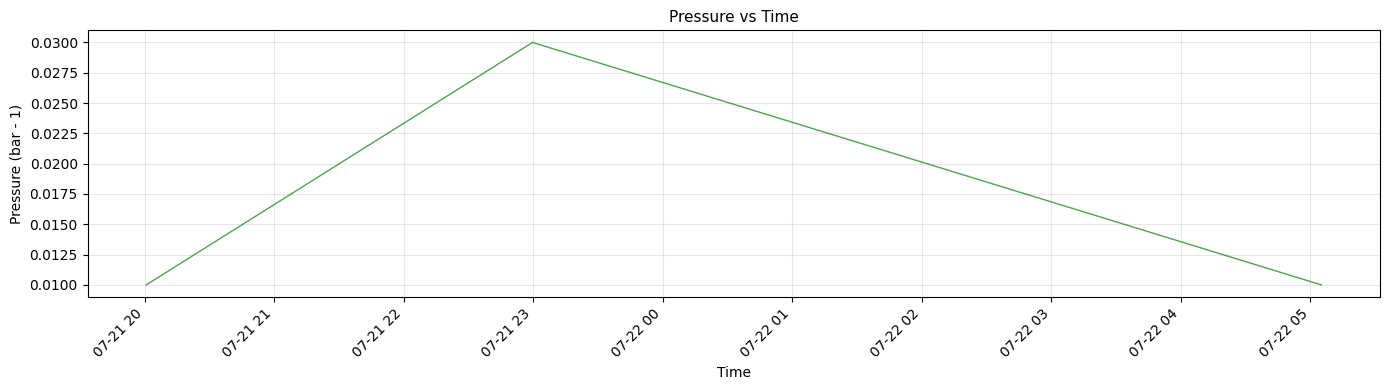

📊 Estadísticas de presión:
   Rango: [0.01, 0.03]
   Media: 0.02
   Std: 0.01
   Puntos válidos: 3


In [4]:
# Plot simple de presión vs tiempo (datos con problemas conocidos)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos
press_valid_mask = press_data_plot > 0
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

if len(press_valid) > 0:
    ax.plot(times_press_valid, press_valid, 'g-', linewidth=1.0, alpha=0.7)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Pressure (bar - 1)', fontsize=10)
    ax.set_title('Pressure vs Time', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Rotar etiquetas del eje X
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}]")
    print(f"   Media: {np.mean(press_valid):.2f}")
    print(f"   Std: {np.std(press_valid):.2f}")
    print(f"   Puntos válidos: {len(press_valid):,}")
else:
    print("⚠️ No hay datos válidos de presión para mostrar")

## 3️⃣ Filtrar Rango Temporal

In [5]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 7, 21)  # ⬅️ CAMBIAR
    t_inicio = datetime.datetime.combine(fecha, datetime.time(14, 25))
    t_fin = datetime.datetime.combine(fecha, datetime.time(23, 10))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos en el rango: {len(times_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-07-21 14:52:16
   Fin:    2026-07-22 10:35:30

✅ Rango seleccionado para análisis:
   2026-07-21 14:25 - 23:10
   Puntos en el rango: 3,721,769


## 4️⃣ Análisis de Temperatura (7 RTDs)

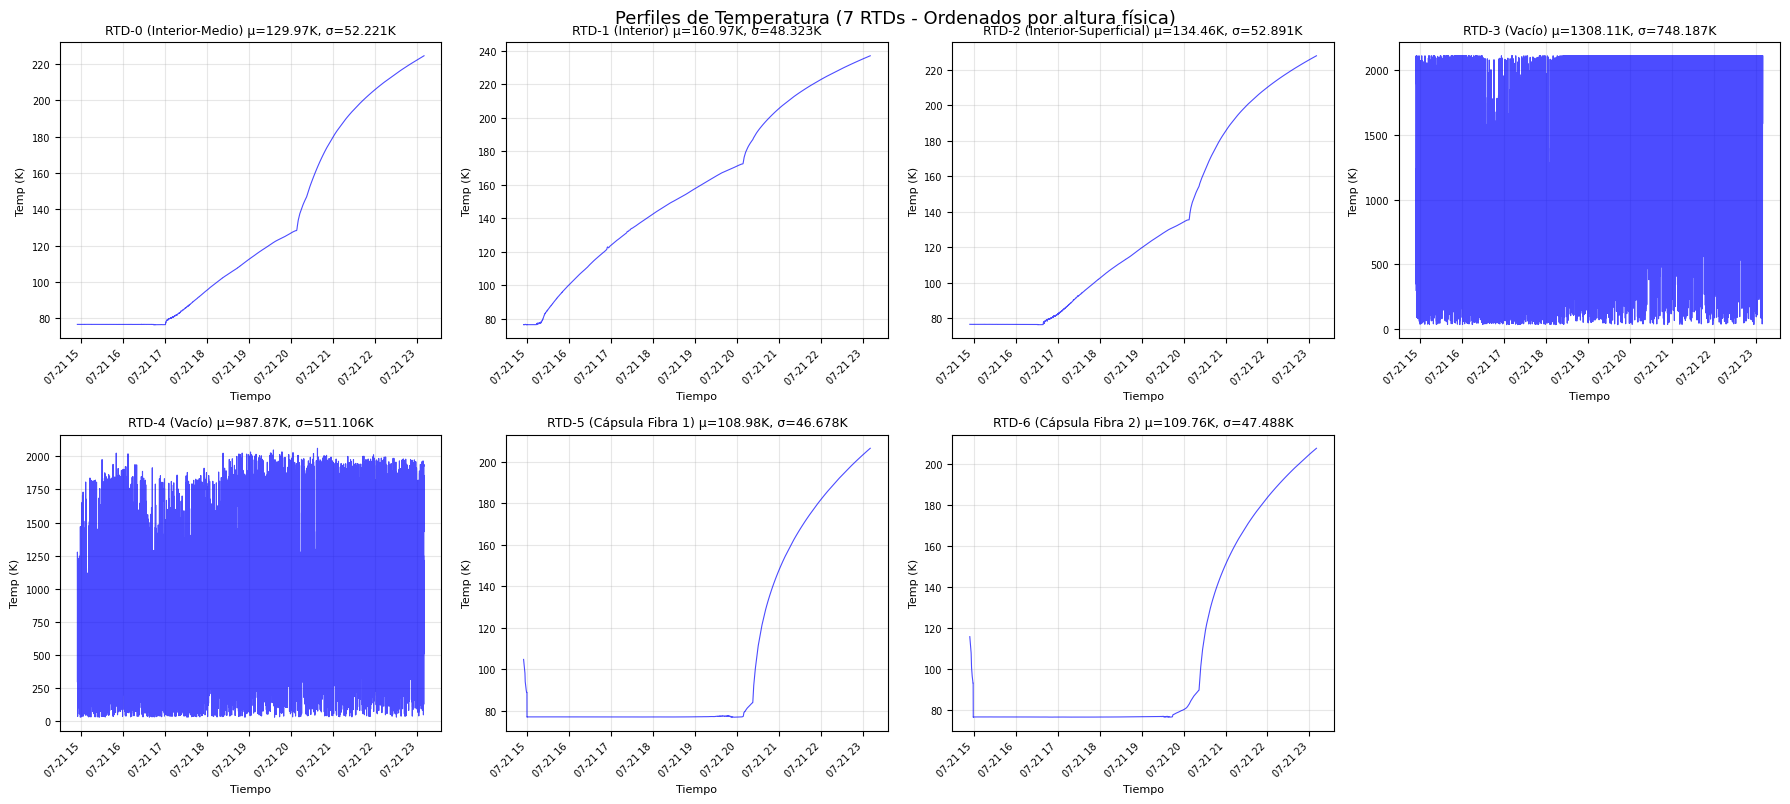

📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Medio)        : μ=129.97K  σ=52.221K
RTD-1 (Interior)              : μ=160.97K  σ=48.323K
RTD-2 (Interior-Superficial)  : μ=134.46K  σ=52.891K
RTD-3 (Vacío)                 : μ=1308.11K  σ=748.187K
RTD-4 (Vacío)                 : μ=987.87K  σ=511.106K
RTD-5 (Cápsula Fibra 1)       : μ=108.98K  σ=46.678K
RTD-6 (Cápsula Fibra 2)       : μ=109.76K  σ=47.488K


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
# Nota: Canal 0 original (Interior-Profundo) omitido por estar roto.
# Matriz de temperatura tiene 7 columnas (índices 0 a 6 en Python).
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Medio)"),         # Medio
    (1, "RTD-1 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (3, "RTD-3 (Vacío)"),                  # Vacío
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Cápsula Fibra 1)"),        # Dentro de cápsula
    (6, "RTD-6 (Cápsula Fibra 2)")         # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
# Ocultar el 8º subplot libre
if len(axes) > len(rtd_sensors_ordered):
    for ax in axes[len(rtd_sensors_ordered):]:
        ax.axis("off")

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, "b-", linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name} μ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel("Tiempo", fontsize=8)
        axes[idx].set_ylabel("Temp (K)", fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")

plt.tight_layout()
plt.suptitle("Perfiles de Temperatura (7 RTDs - Ordenados por altura física)", fontsize=13, y=1.00)
plt.show()

print("📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")


## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [7]:
# ⚠️ CONFIGURACIÓN: Solo 3 sensores funcionales (FBG-4 omitido)
# FBG-4 (sensor 3) no tiene datos en este dataset (desconectado/fallo de hardware)
# 3 sensores × 2 polarizaciones = 6 canales
# Índices 0-based: sensor 0, 1, 2 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    # FBG-4-P y FBG-4-S OMITIDOS (sensor 3 sin datos)
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (3 sensores × 2 polarizaciones)")

✅ Configurados 6 canales FBG (3 sensores × 2 polarizaciones)


### 5.2 Filtrado Wavelength (μ±3σ)

In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (solo sensores funcionales: 0, 1, 2)
print(f"\n🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):")
for sensor_idx in range(3):  # Solo 0, 1, 2 (FBG-4 omitido)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar solo canales configurados (FBG-4 excluido)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (solo sensores funcionales)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (3721769, 2, 3)
   Dimensiones: (time=3721769, pol=2, sensor=3)

🔍 Diagnóstico de valores por sensor (solo FBG-1, FBG-2, FBG-3):
   FBG-1-P: 2617405 pts > 0, range=[1536.12, 1537.44] nm, μ=1536.20 nm
   FBG-1-S: 2616732 pts > 0, range=[1536.12, 1537.44] nm, μ=1536.20 nm
   FBG-2-P: 3646758 pts > 0, range=[1537.60, 1542.28] nm, μ=1539.12 nm
   FBG-2-S: 3646866 pts > 0, range=[1537.60, 1542.28] nm, μ=1539.12 nm
   FBG-3-P: 3560821 pts > 0, range=[1541.06, 1543.61] nm, μ=1542.06 nm
   FBG-3-S: 3561594 pts > 0, range=[1541.06, 1543.61] nm, μ=1542.06 nm

✅ Filtrado completado (solo sensores funcionales)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1536.201841  0.242410     2490440
FBG-1-S      1536.201631  0.241796     2489949
FBG-2-P      1539.123459  0.571494     3612120
FBG-2-S      1539.123773  0.570874     3612228
FBG-3-P      1542.055384  0.397145     3436787
FBG-3-S      1542.055490  0.397744     3437881


### 5.3 Calcular Media de Polarizaciones

In [9]:
# Calcular media P+S para cada sensor (solo sensores funcionales: 1, 2, 3)
# FBG-4 omitido (sin datos)
fbg_mean_data = {}

for sensor_num in [1, 2, 3]:  # Solo sensores funcionales (FBG-4 excluido)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para sensores funcionales")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para sensores funcionales

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1536.153888     0.116925        2490440
FBG-2-Mean      1539.095443     0.497816        3612120
FBG-3-Mean      1542.005761     0.304168        3436787


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

/tmp/vgarciap/ipykernel_2228327/2840626774.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/.venv-fbg/lib64/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


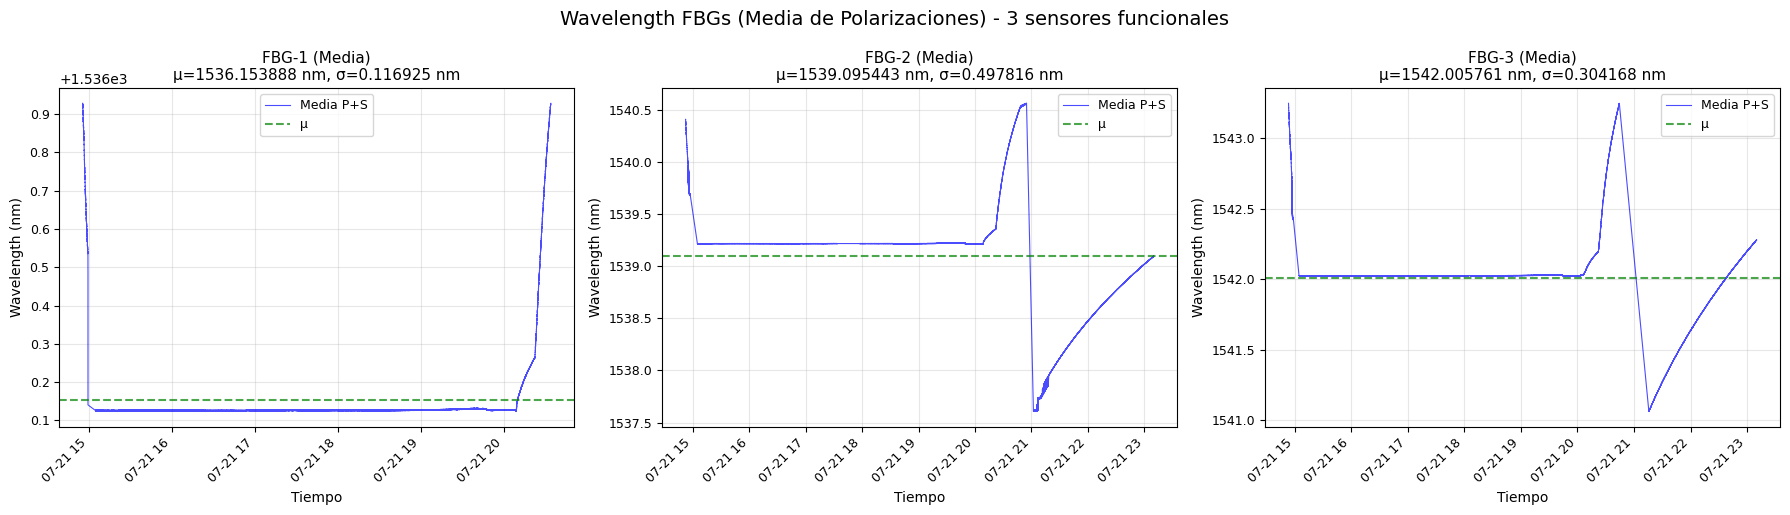

In [10]:
# Ajustar layout para 3 sensores (FBG-4 omitido)
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores funcionales', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [11]:
# Usar RTD-5 (cápsula fibra 1, canal 6) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-7 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

print(f"✅ Referencia: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")

✅ Referencia: RTD-7 (Cápsula)
   Rango: [76.51, 207.74] K


## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

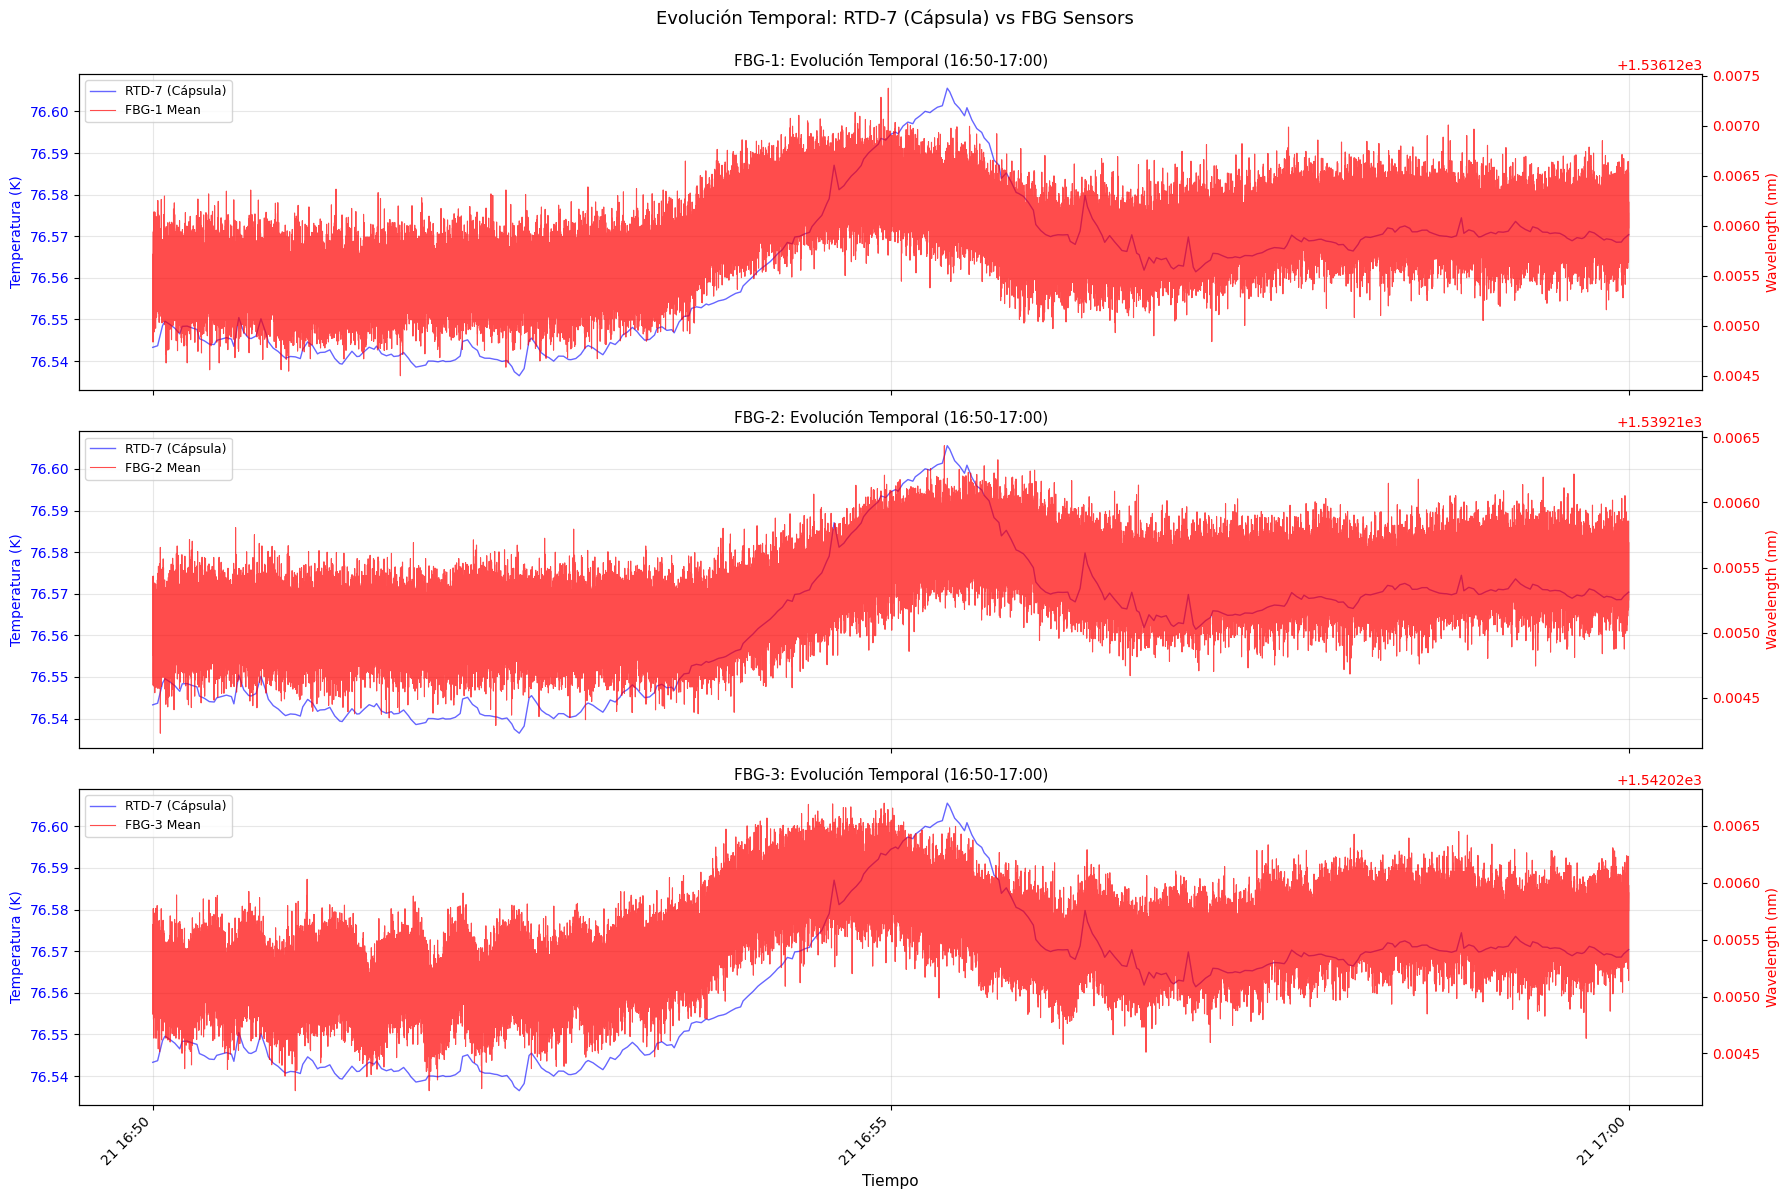


 Rango temporal mostrado: (16:50-17:00)
   Temperatura: 2026-07-21 16:50 - 17:00
   Wavelength (con +0h shift): 2026-07-21 16:50 - 16:59

 Este gráfico muestra el TIME_SHIFT de 0 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [12]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(16, 50))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(17, 0))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label}', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")
if use_filtered_range_plot:
    print(f"\n  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

## 8️⃣ Análisis de Resolución de Temperatura y Comparación FBG vs RTD (< 20 mK)

En esta sección implementamos un análisis progresivo para estudiar la capacidad de resolución de gradientes térmicos del orden de 20 mK de las fibras FBG, comparándolas con los RTDs de referencia.

### Estructura del análisis

| Sección | Objetivo | ¿Qué calcula? |
|---------|----------|---------------|
| **8.1** | Calibración y vista global | Convierte $\lambda$ a $T$, calcula $\sigma$ en plateaus amplios |
| **8.2** | Rango del experimento | Residuos FBG−RTD en el rango 15:30–19:15h con $\sigma$ en plateaus ajustados |
| **8.3** | Prueba de acoplamiento | Compara con RTD-5 (cápsula diferente) para demostrar que la baja $\sigma$ se debe a la cercanía física |
| **8.4** | Plot didáctico de resolución | Zoom al pico + distribución de ruido detrended con límite $3\sigma$ |
| **8.5** | Demostración final | Tracking del pico controlado por los 3 FBG + tabla de resolución |

### Metodología

1. **Calibración Wavelength → Temperatura:** Se convierte la longitud de onda ($\lambda$, en nm) de cada FBG a temperatura absoluta (K) mediante:
$$T_{FBG}(t) = T_0 + \frac{\lambda(t) - \lambda_0}{S}$$
donde $S$ es la sensitividad del sensor en nm/K, y $\lambda_0$ y $T_0$ son los valores promedio en el plateau de calibración.

2. **Downsampling a 2 s:** Se promedian los datos brutos (~100 Hz) en bins de 2 s para reducir el ruido de alta frecuencia sin perder la dinámica térmica.

3. **Cálculo de ruido ($\sigma$):** Se mide la desviación estándar de la temperatura en zonas estables (plateaus). A lo largo de las secciones se refina este cálculo:
   - **Sin detrending** (Celdas 8.1/8.2): $\sigma$ incluye tanto ruido como deriva térmica lenta.
   - **Con detrending lineal** (Celdas 8.4/8.5): Se resta la tendencia lineal del plateau, dejando solo el ruido puro ($\sigma_{net}$). Este es el valor más preciso.

> **Nota:** Los valores de $\sigma$ disminuyen progresivamente a lo largo de las secciones (de ~12 mK en 8.1 a ~2.5 mK en 8.4) porque se refina tanto la ventana temporal del plateau como el método de cálculo (añadiendo detrending). Esto no es una inconsistencia, sino un análisis cada vez más preciso.


✅ RTD de referencia: RTD-7 (Cápsula)
✅ Temperatura de anclaje T0: 76.6194 K
✅ Downsampling: promediando datos cada 2.0 segundos
📊 FBG-1 (S = 18.863 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:10-16:20): 12.240 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.540 mK
--------------------------------------------------------------------------------
📊 FBG-2 (S = 19.338 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:10-16:20): 12.766 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.807 mK
--------------------------------------------------------------------------------
📊 FBG-3 (S = 19.497 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:10-16:20): 4.421 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.349 mK
--------------------------------------------------------------------------------


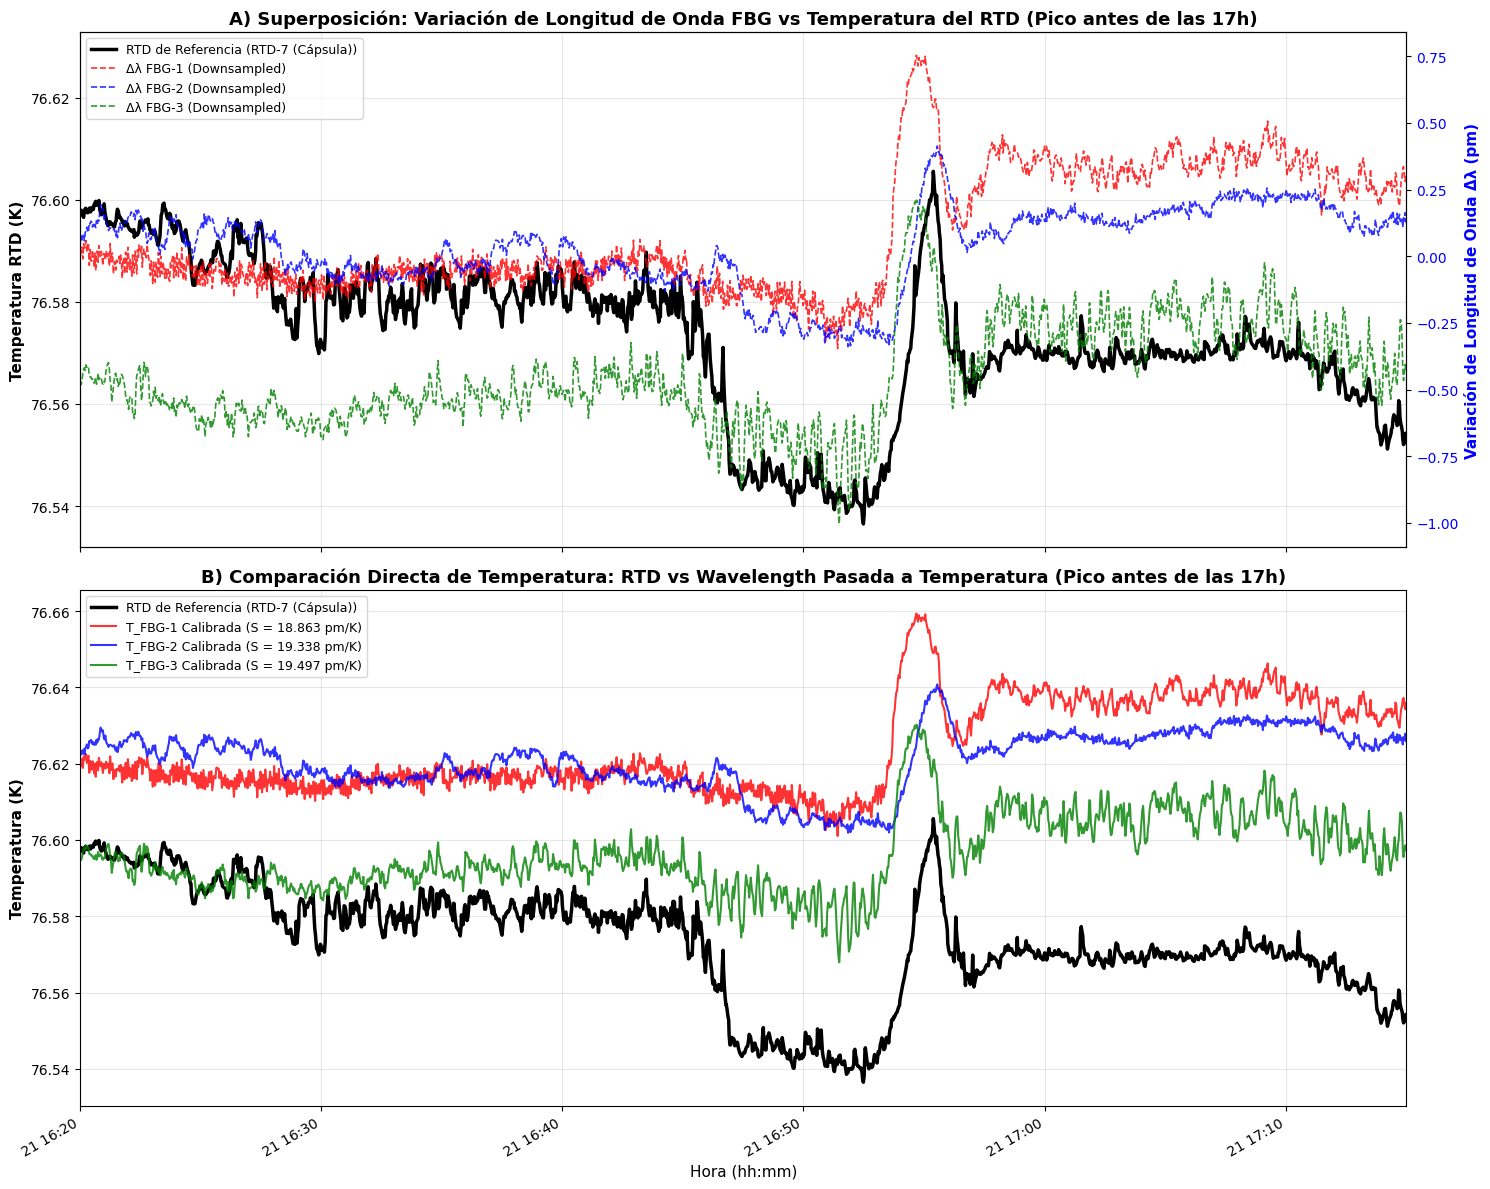

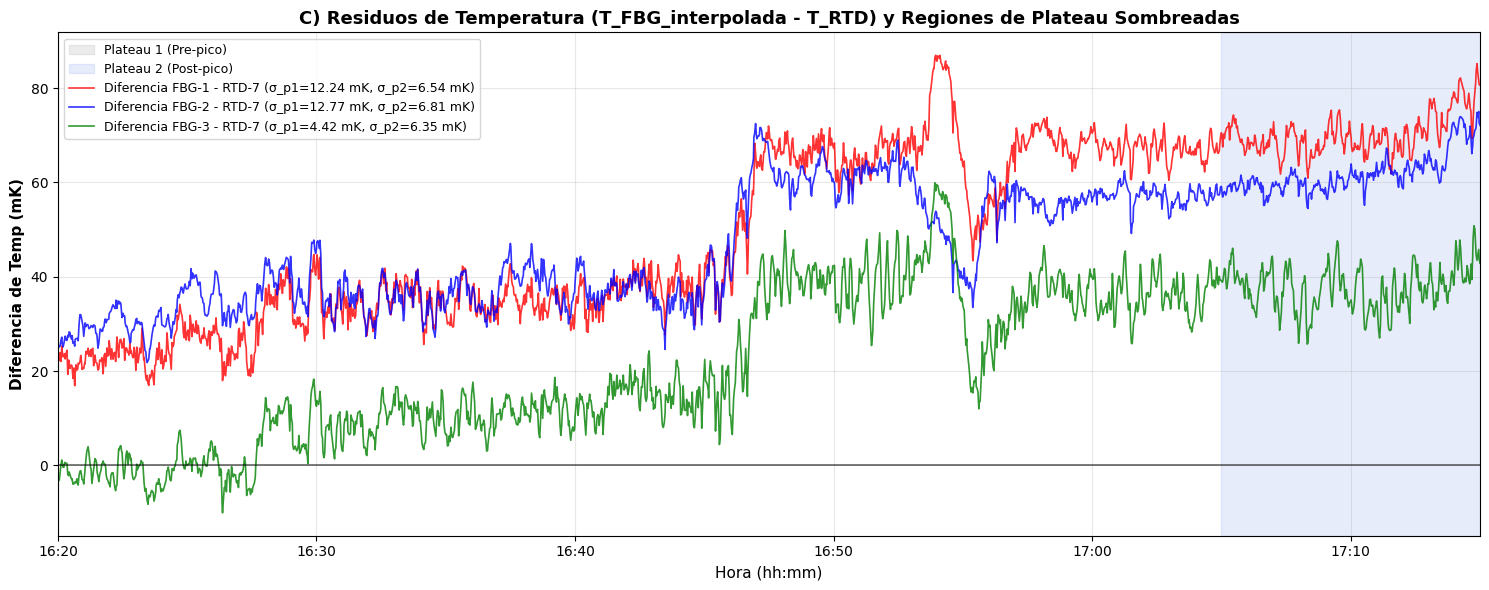

In [13]:
import matplotlib
# ==============================================================================
# ⚙️ CONFIGURACIÓN: PARÁMETROS DE ANÁLISIS Y DOWNSAMPLING
# ==============================================================================

# Parámetro para downsampling temporal (segundos). Cambiar según necesidad:
#   - DOWNSAMPLE_SEC = 1.0 (datos cada 1 segundo)
#   - DOWNSAMPLE_SEC = 2.0 (datos cada 2 segundos)
DOWNSAMPLE_SEC = 2.0

# Rango temporal completo para este análisis
t_analisis_inicio = datetime.datetime.combine(fecha, datetime.time(15, 0))
t_analisis_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))

# Plateau de referencia para calibración (anclaje)
t_baseline_inicio = datetime.datetime.combine(fecha, datetime.time(15, 10))
t_baseline_fin = datetime.datetime.combine(fecha, datetime.time(15, 30))

# Bins de Plateaus Estables para evaluar la resolución (desviación estándar)
# Plateau 1 (Pre-pico)
t_plateau1_inicio = datetime.datetime.combine(fecha, datetime.time(15, 10))
t_plateau1_fin = datetime.datetime.combine(fecha, datetime.time(16, 20))

# Plateau 2 (Post-pico, para doble confirmación)
t_plateau2_inicio = datetime.datetime.combine(fecha, datetime.time(17, 5))
t_plateau2_fin = datetime.datetime.combine(fecha, datetime.time(17, 20))

# Rango de visualización del pico creado antes de las 17:00h
t_zoom_inicio = datetime.datetime.combine(fecha, datetime.time(16, 20))
t_zoom_fin = datetime.datetime.combine(fecha, datetime.time(17, 15))

# Sensitividades medias de los sensores FBG (pm/K)
sensitivities = {
    1: 18.863,  # Sensor 1
    2: 19.338,  # Sensor 2
    3: 19.497   # Sensor 3
}

# Convertir sensitivities a nm/K
sens_nm = {k: v * 1e-3 for k, v in sensitivities.items()}

# 1. Obtener datos de temperatura de referencia (RTD-7, index 6)
rtd_ref_idx = 6
rtd_ref_name = "RTD-7 (Cápsula)"

mask_temp_analysis = (times_temp >= t_analisis_inicio) & (times_temp <= t_analisis_fin) & (temp_raw[:, rtd_ref_idx] > 0)
times_temp_f = times_temp[mask_temp_analysis]
temp_ref_f = temp_raw[mask_temp_analysis, rtd_ref_idx]

# Calcular temperatura T0 en el baseline
mask_baseline_temp = (times_temp_f >= t_baseline_inicio) & (times_temp_f <= t_baseline_fin)
T0 = np.mean(temp_ref_f[mask_baseline_temp])

print(f"✅ RTD de referencia: {rtd_ref_name}")
print(f"✅ Temperatura de anclaje T0: {T0:.4f} K")
print(f"✅ Downsampling: promediando datos cada {DOWNSAMPLE_SEC} segundos")
print("=" * 80)

# 2. Procesar cada FBG sensor con downsampling temporal y conversión a temperatura
from scipy import stats
fbg_calibrated = {}

for sensor_num in [1, 2, 3]:
    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_analisis_inicio) & (times_peak <= t_analisis_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_analisis_inicio) & (times_peak <= t_analisis_fin)
    
    times_p_f = times_peak[mask_p]
    wav_p_f = wav_p_full[mask_p]
    times_s_f = times_peak[mask_s]
    wav_s_f = wav_s_full[mask_s]
    
    if len(times_p_f) == 0 or len(times_s_f) == 0:
        print(f"⚠️ Sensor {sensor_num} sin datos en el rango seleccionado.")
        continue
        
    # Interpolar polarización S a tiempos de P para calcular la media
    times_p_sec = np.array([(t - t_analisis_inicio).total_seconds() for t in times_p_f])
    times_s_sec = np.array([(t - t_analisis_inicio).total_seconds() for t in times_s_f])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s_f)
    wav_mean = (wav_p_f + wav_s_interp) / 2.0
    
    # --- DOWNSAMPLING TEMPORAL SEGURO ---
    duration_sec = (t_analisis_fin - t_analisis_inicio).total_seconds()
    bin_edges = np.arange(0, duration_sec + DOWNSAMPLE_SEC, DOWNSAMPLE_SEC)
    bin_centers = bin_edges[:-1] + DOWNSAMPLE_SEC / 2.0
    
    # Binnar la longitud de onda
    bin_means, _, _ = stats.binned_statistic(times_p_sec, wav_mean, statistic='mean', bins=bin_edges)
    
    # Filtrar bins vacíos
    valid_bins = ~np.isnan(bin_means)
    t_downsampled = np.array([t_analisis_inicio + datetime.timedelta(seconds=float(ts)) for ts in bin_centers[valid_bins]])
    w_downsampled = bin_means[valid_bins]
    
    # Calcular longitud de onda de anclaje (w0) en el baseline usando los datos downsampleados
    mask_baseline_fbg = (t_downsampled >= t_baseline_inicio) & (t_downsampled <= t_baseline_fin)
    w0 = np.mean(w_downsampled[mask_baseline_fbg])
    
    # Convertir a Temperatura FBG usando la sensitividad
    T_fbg = T0 + (w_downsampled - w0) / sens_nm[sensor_num]
    
    # Interpolar T_FBG a los tiempos del RTD para hacer la resta punto a punto
    t_temp_sec = np.array([(t - t_analisis_inicio).total_seconds() for t in times_temp_f])
    t_fbg_sec = np.array([(t - t_analisis_inicio).total_seconds() for t in t_downsampled])
    T_fbg_interp = np.interp(t_temp_sec, t_fbg_sec, T_fbg)
    
    # Calcular residuos en mK
    diff_mK = (T_fbg_interp - temp_ref_f) * 1000.0
    
    # Desviación estándar en el Plateau 1 (Pre-pico: 15:10 - 16:20)
    mask_plat1_temp = (times_temp_f >= t_plateau1_inicio) & (times_temp_f <= t_plateau1_fin)
    std_plateau1 = np.std(diff_mK[mask_plat1_temp])
    
    # Desviación estándar en el Plateau 2 (Post-pico: 17:05 - 17:20)
    mask_plat2_temp = (times_temp_f >= t_plateau2_inicio) & (times_temp_f <= t_plateau2_fin)
    std_plateau2 = np.std(diff_mK[mask_plat2_temp])
    
    fbg_calibrated[sensor_num] = {
        "times": t_downsampled,
        "wav": w_downsampled,
        "temp": T_fbg,
        "temp_interp": T_fbg_interp,
        "diff_mK": diff_mK,
        "w0": w0,
        "std_plateau1": std_plateau1,
        "std_plateau2": std_plateau2
    }
    
    print(f"📊 FBG-{sensor_num} (S = {sensitivities[sensor_num]} pm/K):")
    print(f"   • Std en Plateau 1 (Pre-pico: {t_plateau1_inicio.strftime('%H:%M')}-{t_plateau1_fin.strftime('%H:%M')}): {std_plateau1:.3f} mK")
    print(f"   • Std en Plateau 2 (Post-pico: {t_plateau2_inicio.strftime('%H:%M')}-{t_plateau2_fin.strftime('%H:%M')}): {std_plateau2:.3f} mK")
    print("-" * 80)

# ==============================================================================
# 3. GRÁFICOS DE COMPARACIÓN (SUPERPUESTOS Y ZOOM EN EL PICO ANTES DE LAS 17:00H)
# ==============================================================================
colors_fbg = {1: "red", 2: "blue", 3: "green"}

# Crear figura principal con 2 subplots (rango del pico: 16:20 a 17:15)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# SUBPLOT 1: Variación Wavelength Δλ (pm) y Temperatura del RTD (K) superpuestas (Eje Y dual)
ax1.plot(times_temp_f, temp_ref_f, 'k-', linewidth=2.5, label=f"RTD de Referencia ({rtd_ref_name})")
ax1.set_ylabel("Temperatura RTD (K)", color="black", fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor="black")
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
for sensor_num, data in fbg_calibrated.items():
    t_mask = (data["times"] >= t_zoom_inicio) & (data["times"] <= t_zoom_fin)
    wav_var_pm = (data["wav"][t_mask] - data["w0"]) * 1000.0
    ax1_twin.plot(data["times"][t_mask], wav_var_pm, color=colors_fbg[sensor_num], 
                  linestyle="--", linewidth=1.2, alpha=0.8, label=f"Δλ FBG-{sensor_num} (Downsampled)")

ax1_twin.set_ylabel("Variación de Longitud de Onda Δλ (pm)", color="blue", fontsize=11, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor="blue")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9)
ax1.set_title(f"A) Superposición: Variación de Longitud de Onda FBG vs Temperatura del RTD (Pico antes de las 17h)", 
              fontsize=13, fontweight='bold')
ax1.set_xlim(t_zoom_inicio, t_zoom_fin)

# SUBPLOT 2: Temperatura RTD (K) y Temperatura FBG (K) superpuestas usando sensitividad
ax2.plot(times_temp_f, temp_ref_f, 'k-', linewidth=2.5, label=f"RTD de Referencia ({rtd_ref_name})")
for sensor_num, data in fbg_calibrated.items():
    t_mask = (data["times"] >= t_zoom_inicio) & (data["times"] <= t_zoom_fin)
    ax2.plot(data["times"][t_mask], data["temp"][t_mask], color=colors_fbg[sensor_num], 
              linewidth=1.5, alpha=0.8, label=f"T_FBG-{sensor_num} Calibrada (S = {sensitivities[sensor_num]} pm/K)")

ax2.set_ylabel("Temperatura (K)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Hora (hh:mm)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left", fontsize=9)
ax2.set_title("B) Comparación Directa de Temperatura: RTD vs Wavelength Pasada a Temperatura (Pico antes de las 17h)", 
              fontsize=13, fontweight='bold')

for tick in ax2.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")

plt.tight_layout()
plt.show()

# FIGURA: Residuos T_FBG - T_RTD (mK) para cuantificar la resolución con sombreado de Plateaus
plt.figure(figsize=(15, 6))

# Sombrear los plateaus en el fondo del gráfico
plt.axvspan(t_plateau1_inicio, t_plateau1_fin, color='gray', alpha=0.15, label="Plateau 1 (Pre-pico)")
plt.axvspan(t_plateau2_inicio, t_plateau2_fin, color='royalblue', alpha=0.12, label="Plateau 2 (Post-pico)")

for sensor_num, data in fbg_calibrated.items():
    t_mask_rtd = (times_temp_f >= t_plateau1_inicio) & (times_temp_f <= t_zoom_fin)
    plt.plot(times_temp_f[t_mask_rtd], data["diff_mK"][t_mask_rtd], color=colors_fbg[sensor_num], 
             linewidth=1.2, alpha=0.8, 
             label=f"Diferencia FBG-{sensor_num} - RTD-7 (σ_p1={data['std_plateau1']:.2f} mK, σ_p2={data['std_plateau2']:.2f} mK)")

plt.axhline(0, color="black", linestyle="-", linewidth=1.2, alpha=0.6)
plt.ylabel("Diferencia de Temp (mK)", fontsize=11, fontweight='bold')
plt.xlabel("Hora (hh:mm)", fontsize=11)
plt.title("C) Residuos de Temperatura (T_FBG_interpolada - T_RTD) y Regiones de Plateau Sombreadas", fontsize=13, fontweight='bold')
plt.xlim(t_plateau1_inicio, t_zoom_fin)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=9)
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


### 8.2 Evolución Temporal y Residuos en el Rango del Experimento (15:30h - 19:15h)

En esta sección realizamos el análisis en el rango temporal del experimento (`15:30h` a `19:15h`), que cubre los picos de presión creados al abrir/cerrar la válvula manual.

**Plateau de análisis ajustado:** A diferencia de la Sección 8.1 (que usaba 15:10–16:20h), aquí recortamos el inicio del plateau a **15:40h** porque antes de esa hora la temperatura aún se estaba estabilizando tras el enfriamiento inicial. Esto reduce significativamente la $\sigma$ observada.

Se calcula $\sigma$ (sin detrending) en dos ventanas estables:
- **Plateau 1 (Pre-pico):** `15:40h` a `16:20h`
- **Plateau 2 (Post-pico):** `17:05h` a `17:20h`

Los residuos ($T_{FBG} - T_{RTD}$) y las regiones de plateau se muestran en los plots.


✅ RTD de referencia: RTD-7 (Cápsula)
✅ Rango de Visualización: 15:30 a 18:15 h
✅ Temperatura de anclaje T0: 76.6072 K
✅ Downsampling: promediando datos cada 2.0 segundos
📊 FBG-1 (S = 18.863 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:40-16:20): 3.188 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.540 mK
--------------------------------------------------------------------------------
📊 FBG-2 (S = 19.338 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:40-16:20): 2.435 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.807 mK
--------------------------------------------------------------------------------
📊 FBG-3 (S = 19.497 pm/K):
   • Std en Plateau 1 (Pre-pico: 15:40-16:20): 3.537 mK
   • Std en Plateau 2 (Post-pico: 17:05-17:20): 6.349 mK
--------------------------------------------------------------------------------


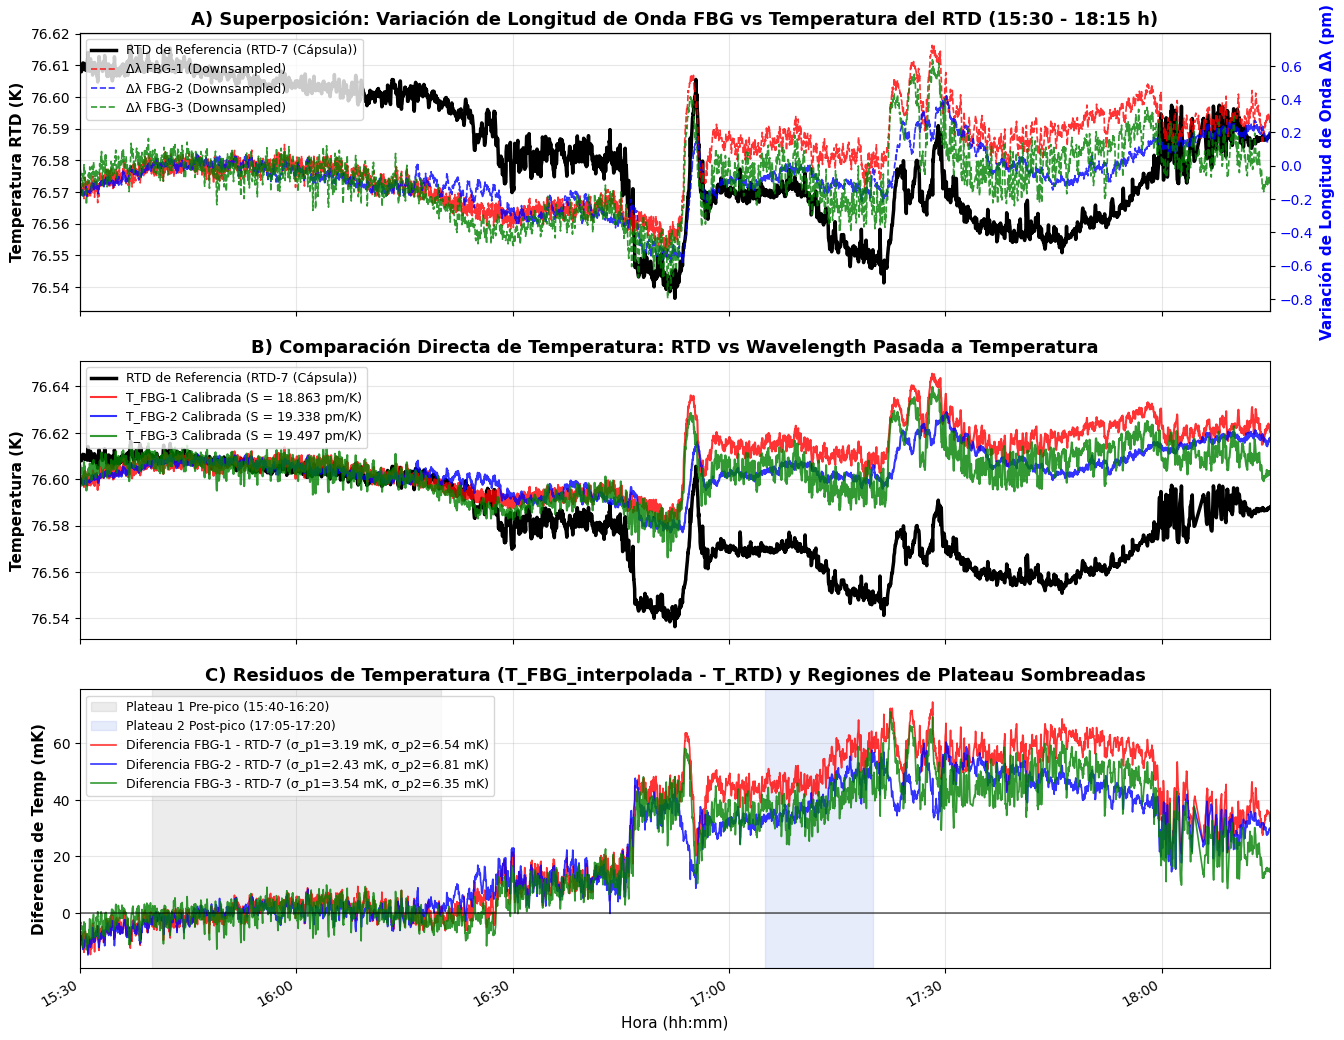

In [14]:
import matplotlib
# ==============================================================================
# CONFIGURACIÓN: RANGO DE TIEMPO DEL EXPERIMENTO (15:30h - 19:15h)
# ==============================================================================

# Parámetro para downsampling temporal (segundos)
DOWNSAMPLE_SEC = 2.0

# Filtrado de rango temporal solicitado (15:30h a 19:15h)
t_comp_inicio = datetime.datetime.combine(fecha, datetime.time(15, 30))
t_comp_fin = datetime.datetime.combine(fecha, datetime.time(18, 15))

# Baseline de anclaje (dentro del rango de análisis: 15:40h a 16:00h)
t_baseline_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_baseline_fin = datetime.datetime.combine(fecha, datetime.time(16, 0))

# Plateau 1 (Pre-pico, antes de las 16:50h)
t_plateau1_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_plateau1_fin = datetime.datetime.combine(fecha, datetime.time(16, 20))

# Plateau 2 (Post-pico, después de las 17:00h)
t_plateau2_inicio = datetime.datetime.combine(fecha, datetime.time(17, 5))
t_plateau2_fin = datetime.datetime.combine(fecha, datetime.time(17, 20))

# Sensitividades medias de los sensores FBG (pm/K)
sensitivities = {
    1: 18.863,  # Sensor 1
    2: 19.338,  # Sensor 2
    3: 19.497   # Sensor 3
}

# Convertir sensitivities a nm/K
sens_nm = {k: v * 1e-3 for k, v in sensitivities.items()}

# 1. Obtener datos del RTD de referencia (RTD-7, index 6)
rtd_ref_idx = 6
rtd_ref_name = "RTD-7 (Cápsula)"

mask_temp_comp = (times_temp >= t_comp_inicio) & (times_temp <= t_comp_fin) & (temp_raw[:, rtd_ref_idx] > 0)
times_temp_fc = times_temp[mask_temp_comp]
temp_ref_fc = temp_raw[mask_temp_comp, rtd_ref_idx]

# Calcular temperatura T0 en el baseline
mask_baseline_temp = (times_temp_fc >= t_baseline_inicio) & (times_temp_fc <= t_baseline_fin)
T0 = np.mean(temp_ref_fc[mask_baseline_temp])

print(f"✅ RTD de referencia: {rtd_ref_name}")
print(f"✅ Rango de Visualización: {t_comp_inicio.strftime('%H:%M')} a {t_comp_fin.strftime('%H:%M')} h")
print(f"✅ Temperatura de anclaje T0: {T0:.4f} K")
print(f"✅ Downsampling: promediando datos cada {DOWNSAMPLE_SEC} segundos")
print("=" * 80)

# 2. Procesar cada FBG sensor con downsampling y conversión a temperatura
from scipy import stats
fbg_calibrated_comp = {}

for sensor_num in [1, 2, 3]:
    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin)
    
    times_p_f = times_peak[mask_p]
    wav_p_f = wav_p_full[mask_p]
    times_s_f = times_peak[mask_s]
    wav_s_f = wav_s_full[mask_s]
    
    if len(times_p_f) == 0 or len(times_s_f) == 0:
        continue
        
    # Interpolar polarización S a tiempos de P para calcular la media (timezone safe)
    times_p_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_p_f])
    times_s_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_s_f])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s_f)
    wav_mean = (wav_p_f + wav_s_interp) / 2.0
    
    # --- DOWNSAMPLING TEMPORAL SEGURO ---
    duration_sec = (t_comp_fin - t_comp_inicio).total_seconds()
    bin_edges = np.arange(0, duration_sec + DOWNSAMPLE_SEC, DOWNSAMPLE_SEC)
    bin_centers = bin_edges[:-1] + DOWNSAMPLE_SEC / 2.0
    
    # Binnar la longitud de onda
    bin_means, _, _ = stats.binned_statistic(times_p_sec, wav_mean, statistic='mean', bins=bin_edges)
    
    # Filtrar bins vacíos
    valid_bins = ~np.isnan(bin_means)
    t_downsampled = np.array([t_comp_inicio + datetime.timedelta(seconds=float(ts)) for ts in bin_centers[valid_bins]])
    w_downsampled = bin_means[valid_bins]
    
    # Calcular longitud de onda de anclaje (w0) en el baseline usando los datos downsampleados
    mask_baseline_fbg = (t_downsampled >= t_baseline_inicio) & (t_downsampled <= t_baseline_fin)
    w0 = np.mean(w_downsampled[mask_baseline_fbg])
    
    # Convertir a Temperatura FBG usando la sensitividad
    T_fbg = T0 + (w_downsampled - w0) / sens_nm[sensor_num]
    
    # Interpolar T_FBG a los tiempos del RTD para hacer la resta punto a punto
    t_temp_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_temp_fc])
    t_fbg_sec = np.array([(t - t_comp_inicio).total_seconds() for t in t_downsampled])
    T_fbg_interp = np.interp(t_temp_sec, t_fbg_sec, T_fbg)
    
    # Calcular residuos en mK
    diff_mK = (T_fbg_interp - temp_ref_fc) * 1000.0
    
    # Desviación estándar en Plateau 1 (Pre-pico: 15:40h - 16:20h)
    mask_plat1_temp = (times_temp_fc >= t_plateau1_inicio) & (times_temp_fc <= t_plateau1_fin)
    std_plateau1 = np.std(diff_mK[mask_plat1_temp])
    
    # Desviación estándar en Plateau 2 (Post-pico: 17:05h - 17:20h)
    mask_plat2_temp = (times_temp_fc >= t_plateau2_inicio) & (times_temp_fc <= t_plateau2_fin)
    std_plateau2 = np.std(diff_mK[mask_plat2_temp])
    
    fbg_calibrated_comp[sensor_num] = {
        "times": t_downsampled,
        "wav": w_downsampled,
        "temp": T_fbg,
        "temp_interp": T_fbg_interp,
        "diff_mK": diff_mK,
        "w0": w0,
        "std_plateau1": std_plateau1,
        "std_plateau2": std_plateau2
    }
    
    print(f"📊 FBG-{sensor_num} (S = {sensitivities[sensor_num]} pm/K):")
    print(f"   • Std en Plateau 1 (Pre-pico: {t_plateau1_inicio.strftime('%H:%M')}-{t_plateau1_fin.strftime('%H:%M')}): {std_plateau1:.3f} mK")
    print(f"   • Std en Plateau 2 (Post-pico: {t_plateau2_inicio.strftime('%H:%M')}-{t_plateau2_fin.strftime('%H:%M')}): {std_plateau2:.3f} mK")
    print("-" * 80)

# ==============================================================================
# 3. GRÁFICOS EN EL RANGO DEL EXPERIMENTO (15:30h - 19:15h)
# ==============================================================================
colors_fbg = {1: "red", 2: "blue", 3: "green"}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# ------------------------------------------------------------------------------
# SUBPLOT A: Variación Wavelength Δλ (pm) y Temperatura del RTD (K) superpuestas (Eje Y dual)
# ------------------------------------------------------------------------------
ax1.plot(times_temp_fc, temp_ref_fc, 'k-', linewidth=2.5, label=f"RTD de Referencia ({rtd_ref_name})")
ax1.set_ylabel("Temperatura RTD (K)", color="black", fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor="black")
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
for sensor_num, data in fbg_calibrated_comp.items():
    # Variación de longitud de onda relativa en pm
    wav_var_pm = (data["wav"] - data["w0"]) * 1000.0
    ax1_twin.plot(data["times"], wav_var_pm, color=colors_fbg[sensor_num], 
                  linestyle="--", linewidth=1.2, alpha=0.8, label=f"Δλ FBG-{sensor_num} (Downsampled)")

ax1_twin.set_ylabel("Variación de Longitud de Onda Δλ (pm)", color="blue", fontsize=11, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor="blue")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9)
ax1.set_title(f"A) Superposición: Variación de Longitud de Onda FBG vs Temperatura del RTD ({t_comp_inicio.strftime('%H:%M')} - {t_comp_fin.strftime('%H:%M')} h)", 
              fontsize=13, fontweight='bold')
ax1.set_xlim(t_comp_inicio, t_comp_fin)

# ------------------------------------------------------------------------------
# SUBPLOT B: Temperatura RTD (K) y Temperatura FBG (K) superpuestas usando sensitividad
# ------------------------------------------------------------------------------
ax2.plot(times_temp_fc, temp_ref_fc, 'k-', linewidth=2.5, label=f"RTD de Referencia ({rtd_ref_name})")
for sensor_num, data in fbg_calibrated_comp.items():
    ax2.plot(data["times"], data["temp"], color=colors_fbg[sensor_num], 
              linewidth=1.5, alpha=0.8, label=f"T_FBG-{sensor_num} Calibrada (S = {sensitivities[sensor_num]} pm/K)")

ax2.set_ylabel("Temperatura (K)", fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left", fontsize=9)
ax2.set_title("B) Comparación Directa de Temperatura: RTD vs Wavelength Pasada a Temperatura", 
              fontsize=13, fontweight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT C: Residuos T_FBG - T_RTD (mK) con sombreado de regiones de Plateaus y Leyenda con Sigmas
# ------------------------------------------------------------------------------
# Sombrear los dos plateaus estables en el fondo del gráfico
ax3.axvspan(t_plateau1_inicio, t_plateau1_fin, color='gray', alpha=0.15, label=f"Plateau 1 Pre-pico ({t_plateau1_inicio.strftime('%H:%M')}-{t_plateau1_fin.strftime('%H:%M')})")
ax3.axvspan(t_plateau2_inicio, t_plateau2_fin, color='royalblue', alpha=0.12, label=f"Plateau 2 Post-pico ({t_plateau2_inicio.strftime('%H:%M')}-{t_plateau2_fin.strftime('%H:%M')})")

for sensor_num, data in fbg_calibrated_comp.items():
    ax3.plot(times_temp_fc, data["diff_mK"], color=colors_fbg[sensor_num], 
             linewidth=1.2, alpha=0.8, 
             label=f"Diferencia FBG-{sensor_num} - RTD-7 (σ_p1={data['std_plateau1']:.2f} mK, σ_p2={data['std_plateau2']:.2f} mK)")

ax3.axhline(0, color="black", linestyle="-", linewidth=1.2, alpha=0.6)
ax3.set_ylabel("Diferencia de Temp (mK)", fontsize=11, fontweight='bold')
ax3.set_xlabel("Hora (hh:mm)", fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.legend(loc="upper left", fontsize=9)
ax3.set_title("C) Residuos de Temperatura (T_FBG_interpolada - T_RTD) y Regiones de Plateau Sombreadas", fontsize=13, fontweight='bold')

ax3.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
for tick in ax3.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")

plt.subplots_adjust(hspace=0.18, top=0.93, bottom=0.08, left=0.07, right=0.92)
plt.show()


### 8.3 Demostración de Acoplamiento Térmico: Comparación con el RTD-5 (Cápsula Fibra 1)

Para verificar que la baja $\sigma$ obtenida en la Sección 8.2 se debe al **acoplamiento térmico directo** (cercanía física entre FBG y RTD-7 dentro de la misma cápsula) y no a un artefacto del análisis, repetimos el cálculo de residuos utilizando como referencia el **RTD-5** (situado en una cápsula diferente dentro de la vasija).

**Resultado esperado:** Si la baja $\sigma$ se debe a la cercanía, al usar un RTD más alejado la $\sigma$ debería **aumentar**.

**Resultado observado:**
- Con RTD-7 (misma cápsula): $\sigma \sim 2\text{–}3$ mK
- Con RTD-5 (otra cápsula): $\sigma \sim 5\text{–}6$ mK (el doble)
- Con un RTD exterior a la cápsula: $\sigma > 50$ mK

Esto confirma que las fibras FBG miden con precisión milikelvin cuando están acopladas térmicamente al punto de medida.


✅ RTD de referencia alternativo: RTD-5 (Cápsula Fibra 1)
✅ Rango de Visualización: 15:30 a 19:15 h
✅ Temperatura de anclaje T0: 77.1503 K
📊 FBG-1 vs RTD-5 (Cápsula Fibra 1):
   • Std en Plateau 1 (Pre-pico): 5.960 mK
   • Std en Plateau 2 (Post-pico): 4.308 mK
--------------------------------------------------------------------------------
📊 FBG-2 vs RTD-5 (Cápsula Fibra 1):
   • Std en Plateau 1 (Pre-pico): 5.586 mK
   • Std en Plateau 2 (Post-pico): 3.849 mK
--------------------------------------------------------------------------------
📊 FBG-3 vs RTD-5 (Cápsula Fibra 1):
   • Std en Plateau 1 (Pre-pico): 5.878 mK
   • Std en Plateau 2 (Post-pico): 5.559 mK
--------------------------------------------------------------------------------


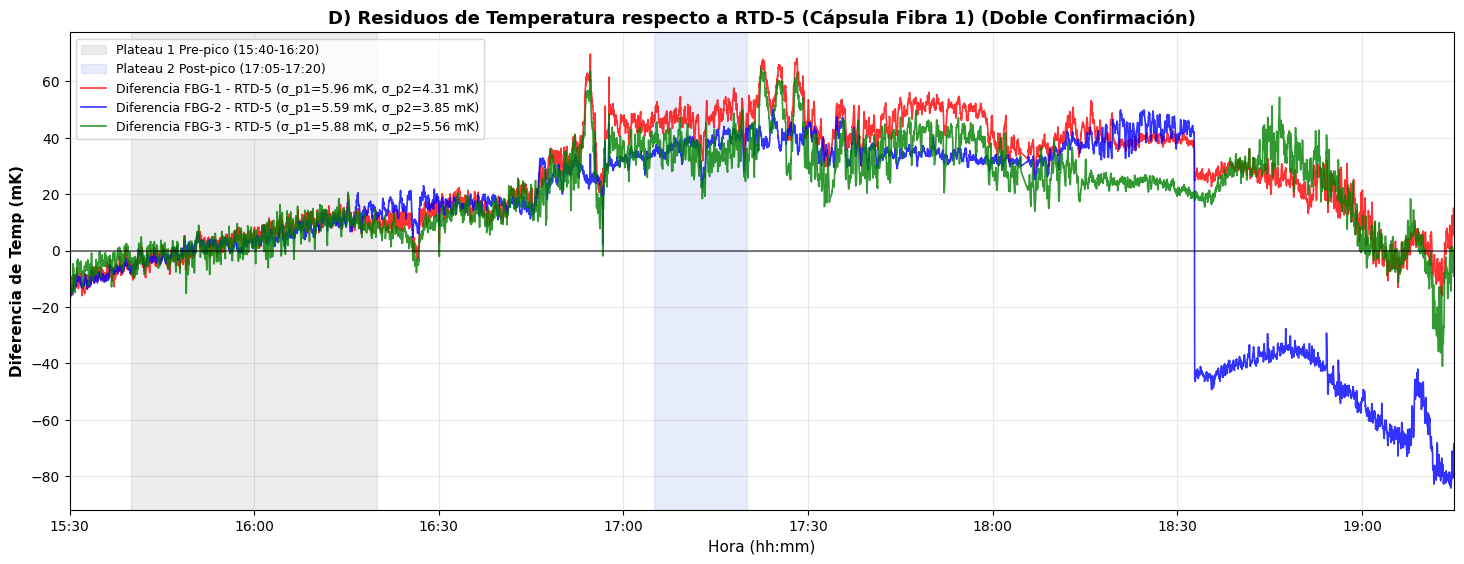

In [15]:
import matplotlib
# ==============================================================================
# CONFIGURACIÓN: ANÁLISIS IDÉNTICO CON EL OTRO RTD DE LA CÁPSULA (RTD-5, index 5)
# ==============================================================================

# Parámetro para downsampling temporal (segundos)
DOWNSAMPLE_SEC = 2.0

# Filtrado de rango temporal (15:30h a 19:15h)
t_comp_inicio = datetime.datetime.combine(fecha, datetime.time(15, 30))
t_comp_fin = datetime.datetime.combine(fecha, datetime.time(19, 15))

# Baseline de anclaje (15:40h a 16:00h)
t_baseline_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_baseline_fin = datetime.datetime.combine(fecha, datetime.time(16, 0))

# Plateaus estables para evaluar la resolución
t_plateau1_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_plateau1_fin = datetime.datetime.combine(fecha, datetime.time(16, 20))
t_plateau2_inicio = datetime.datetime.combine(fecha, datetime.time(17, 5))
t_plateau2_fin = datetime.datetime.combine(fecha, datetime.time(17, 20))

# Sensitividades medias (pm/K)
sensitivities = {
    1: 18.863,
    2: 19.338,
    3: 19.497
}
sens_nm = {k: v * 1e-3 for k, v in sensitivities.items()}

# 1. Obtener datos del OTRO RTD de referencia (RTD-5, index 5)
rtd_ref_idx = 5
rtd_ref_name = "RTD-5 (Cápsula Fibra 1)"

mask_temp_comp = (times_temp >= t_comp_inicio) & (times_temp <= t_comp_fin) & (temp_raw[:, rtd_ref_idx] > 0)
times_temp_fc = times_temp[mask_temp_comp]
temp_ref_fc = temp_raw[mask_temp_comp, rtd_ref_idx]

# Calcular temperatura T0 en el baseline
mask_baseline_temp = (times_temp_fc >= t_baseline_inicio) & (times_temp_fc <= t_baseline_fin)
T0 = np.mean(temp_ref_fc[mask_baseline_temp])

print(f"✅ RTD de referencia alternativo: {rtd_ref_name}")
print(f"✅ Rango de Visualización: {t_comp_inicio.strftime('%H:%M')} a {t_comp_fin.strftime('%H:%M')} h")
print(f"✅ Temperatura de anclaje T0: {T0:.4f} K")
print("=" * 80)

# 2. Procesar cada FBG sensor
from scipy import stats
fbg_calibrated_comp = {}

for sensor_num in [1, 2, 3]:
    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]
    
    mask_p = (wav_p_full > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin)
    
    times_p_f = times_peak[mask_p]
    wav_p_f = wav_p_full[mask_p]
    times_s_f = times_peak[mask_s]
    wav_s_f = wav_s_full[mask_s]
    
    if len(times_p_f) == 0 or len(times_s_f) == 0:
        continue
        
    times_p_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_p_f])
    times_s_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_s_f])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s_f)
    wav_mean = (wav_p_f + wav_s_interp) / 2.0
    
    # --- DOWNSAMPLING ---
    duration_sec = (t_comp_fin - t_comp_inicio).total_seconds()
    bin_edges = np.arange(0, duration_sec + DOWNSAMPLE_SEC, DOWNSAMPLE_SEC)
    bin_centers = bin_edges[:-1] + DOWNSAMPLE_SEC / 2.0
    
    bin_means, _, _ = stats.binned_statistic(times_p_sec, wav_mean, statistic='mean', bins=bin_edges)
    valid_bins = ~np.isnan(bin_means)
    t_downsampled = np.array([t_comp_inicio + datetime.timedelta(seconds=float(ts)) for ts in bin_centers[valid_bins]])
    w_downsampled = bin_means[valid_bins]
    
    mask_baseline_fbg = (t_downsampled >= t_baseline_inicio) & (t_downsampled <= t_baseline_fin)
    w0 = np.mean(w_downsampled[mask_baseline_fbg])
    
    T_fbg = T0 + (w_downsampled - w0) / sens_nm[sensor_num]
    
    t_temp_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_temp_fc])
    t_fbg_sec = np.array([(t - t_comp_inicio).total_seconds() for t in t_downsampled])
    T_fbg_interp = np.interp(t_temp_sec, t_fbg_sec, T_fbg)
    
    diff_mK = (T_fbg_interp - temp_ref_fc) * 1000.0
    
    # Sigmas
    mask_plat1_temp = (times_temp_fc >= t_plateau1_inicio) & (times_temp_fc <= t_plateau1_fin)
    std_plateau1 = np.std(diff_mK[mask_plat1_temp])
    
    mask_plat2_temp = (times_temp_fc >= t_plateau2_inicio) & (times_temp_fc <= t_plateau2_fin)
    std_plateau2 = np.std(diff_mK[mask_plat2_temp])
    
    fbg_calibrated_comp[sensor_num] = {
        "times": t_downsampled,
        "wav": w_downsampled,
        "temp": T_fbg,
        "diff_mK": diff_mK,
        "std_plateau1": std_plateau1,
        "std_plateau2": std_plateau2
    }
    
    print(f"📊 FBG-{sensor_num} vs {rtd_ref_name}:")
    print(f"   • Std en Plateau 1 (Pre-pico): {std_plateau1:.3f} mK")
    print(f"   • Std en Plateau 2 (Post-pico): {std_plateau2:.3f} mK")
    print("-" * 80)

# 3. GRÁFICO DE RESIDUOS DE DOBLE CONFIRMACIÓN
plt.figure(figsize=(15, 6))
plt.axvspan(t_plateau1_inicio, t_plateau1_fin, color='gray', alpha=0.15, label=f"Plateau 1 Pre-pico ({t_plateau1_inicio.strftime('%H:%M')}-{t_plateau1_fin.strftime('%H:%M')})")
plt.axvspan(t_plateau2_inicio, t_plateau2_fin, color='royalblue', alpha=0.12, label=f"Plateau 2 Post-pico ({t_plateau2_inicio.strftime('%H:%M')}-{t_plateau2_fin.strftime('%H:%M')})")

colors_fbg = {1: "red", 2: "blue", 3: "green"}
for sensor_num, data in fbg_calibrated_comp.items():
    plt.plot(times_temp_fc, data["diff_mK"], color=colors_fbg[sensor_num], 
             linewidth=1.2, alpha=0.8, 
             label=f"Diferencia FBG-{sensor_num} - RTD-5 (σ_p1={data['std_plateau1']:.2f} mK, σ_p2={data['std_plateau2']:.2f} mK)")

plt.axhline(0, color="black", linestyle="-", linewidth=1.2, alpha=0.6)
plt.ylabel("Diferencia de Temp (mK)", fontsize=11, fontweight='bold')
plt.xlabel("Hora (hh:mm)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=9)
plt.title(f"D) Residuos de Temperatura respecto a {rtd_ref_name} (Doble Confirmación)", fontsize=13, fontweight='bold')
plt.xlim(t_comp_inicio, t_comp_fin)
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
plt.tight_layout(pad=2.0)
plt.show()


### 8.4 Demostración Didáctica de Resolución de Temperatura

En esta sección refinamos el cálculo de ruido aplicando **detrending lineal** al plateau estable (15:40h–16:20h). Este paso elimina la deriva térmica lenta ($\sim 0.1$ mK/min) y aísla el ruido instrumental puro de cada FBG.

**¿Por qué detrending?** En las secciones anteriores, la $\sigma$ calculada incluía tanto el ruido real como la deriva lenta del sistema. Al restar una recta de ajuste ($T = a \cdot t + b$), eliminamos la componente de primer orden de la deriva y obtenemos $\sigma_{net}$ — el ruido neto del sensor.

**Plots:**
- **A) Zoom al pico de presión (~70 mK):** Los 3 FBG y el RTD trackean la misma forma del pico. La banda sombreada indica el nivel de ruido $\pm 3\sigma$, mostrando que el pico está muy por encima del ruido.
- **B) Distribución del ruido de los 3 FBG:** Histogramas de las fluctuaciones en el plateau (detrended) con ajustes gaussianos. Se muestra una flecha indicando 20 mK para comparar visualmente con la anchura de la distribución de ruido.


Desviaciones estándar del ruido neto (Plateau 15:40h - 16:20h):
  • FBG-1: 2.531 mK (Límite 3σ: 7.593 mK)
  • FBG-2: 1.762 mK (Límite 3σ: 5.287 mK)
  • FBG-3: 3.263 mK (Límite 3σ: 9.788 mK)


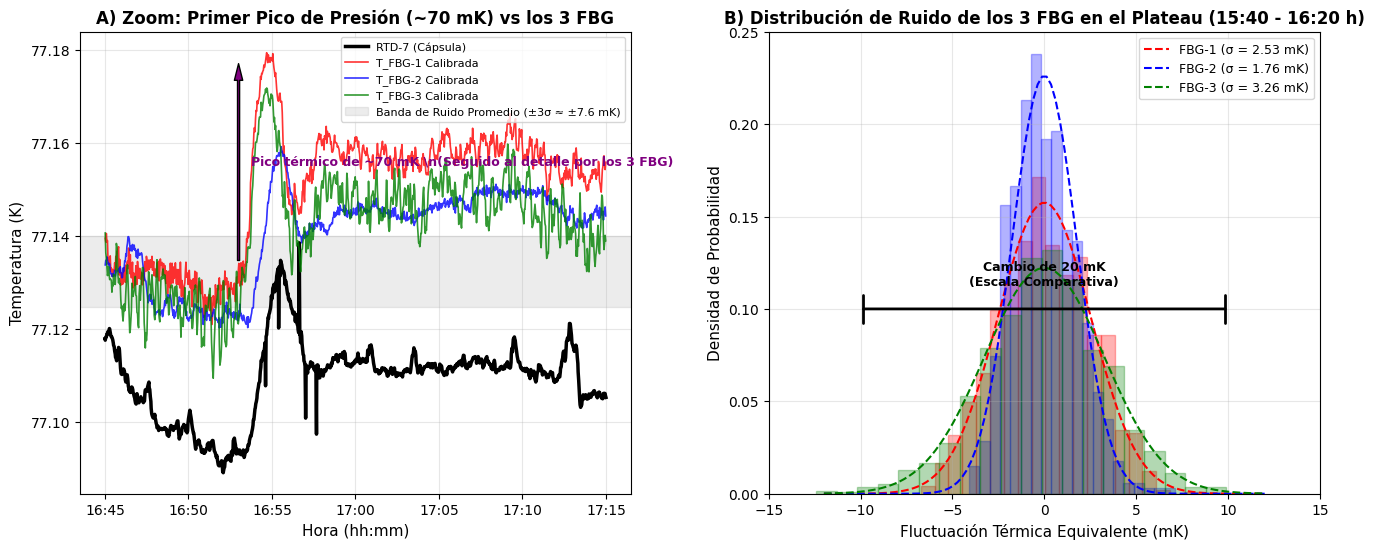

In [16]:
import matplotlib
# ==============================================================================
# CONFIGURACIÓN: CÁLCULO DE RUIDO Y PLOT DIDÁCTICO DE RESOLUCIÓN (ZOOM AL PICO - 3 FBGs)
# ==============================================================================

# Rango para el histograma de ruido (Plateau 1)
t_plateau1_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_plateau1_fin = datetime.datetime.combine(fecha, datetime.time(16, 20))

# Rango de zoom centrado en el primer pico inducido por presión antes de las 17h
t_zoom_i = datetime.datetime.combine(fecha, datetime.time(16, 45))
t_zoom_f = datetime.datetime.combine(fecha, datetime.time(17, 15))

# 1. Extraer datos y calcular ruido neto para los 3 FBG
fbg_data = {}
for sensor_num in [1, 2, 3]:
    data_sensor = fbg_calibrated_comp[sensor_num]
    t_f = data_sensor["times"]
    T_f = data_sensor["temp"]
    
    # Calcular fluctuaciones durante el plateau estable
    mask_plat = (t_f >= t_plateau1_inicio) & (t_f <= t_plateau1_fin)
    T_f_plat = T_f[mask_plat]
    
    # Restar tendencia lineal para ruido neto
    x_plat = np.array([(t - t_plateau1_inicio).total_seconds() for t in t_f[mask_plat]])
    slope, intercept, _, _, _ = stats.linregress(x_plat, T_f_plat)
    noise_f = (T_f_plat - (slope * x_plat + intercept)) * 1000.0  # a mK
    std_noise = np.std(noise_f)
    
    fbg_data[sensor_num] = {
        "times": t_f,
        "temp": T_f,
        "noise": noise_f,
        "std": std_noise
    }

print("Desviaciones estándar del ruido neto (Plateau 15:40h - 16:20h):")
for s_num in [1, 2, 3]:
    print(f"  • FBG-{s_num}: {fbg_data[s_num]['std']:.3f} mK (Límite 3σ: {3*fbg_data[s_num]['std']:.3f} mK)")
print("=" * 80)

# 2. CREAR FIGURA COMPARATIVA DIDÁCTICA CON LOS 3 SENSORES FBG
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_fbg = {1: "red", 2: "blue", 3: "green"}

# ------------------------------------------------------------------------------
# SUBPLOT A: Zoom del primer pico de presión (~70 mK) vs los 3 sensores FBG
# ------------------------------------------------------------------------------
mask_t_zoom_rtd = (times_temp_fc >= t_zoom_i) & (times_temp_fc <= t_zoom_f)
ax1.plot(times_temp_fc[mask_t_zoom_rtd], temp_ref_fc[mask_t_zoom_rtd], 'k-', linewidth=2.5, label="RTD-7 (Cápsula)")

for s_num in [1, 2, 3]:
    mask_t_zoom_fbg = (fbg_data[s_num]["times"] >= t_zoom_i) & (fbg_data[s_num]["times"] <= t_zoom_f)
    ax1.plot(fbg_data[s_num]["times"][mask_t_zoom_fbg], fbg_data[s_num]["temp"][mask_t_zoom_fbg], 
             color=colors_fbg[s_num], linewidth=1.2, alpha=0.8, label=f"T_FBG-{s_num} Calibrada")

# Calcular temperatura base promedio para centrar la banda de ruido promedio
mask_flat_before = (fbg_data[1]["times"] >= datetime.datetime.combine(fecha, datetime.time(16, 46))) & \
                     (fbg_data[1]["times"] <= datetime.datetime.combine(fecha, datetime.time(16, 49)))
y_baseline = np.mean(fbg_data[1]["temp"][mask_flat_before])
avg_std = np.mean([fbg_data[s]["std"] for s in [1, 2, 3]])

# Dibujar banda de ruido promedio de los FBG (±3σ)
ax1.axhspan(y_baseline - 3*avg_std*1e-3, y_baseline + 3*avg_std*1e-3, color='gray', alpha=0.15, 
            label=f"Banda de Ruido Promedio (±3σ ≈ ±{3*avg_std:.1f} mK)")

# Dibujar flecha indicando el pico térmico inducido
# Dibujar flecha indicando el pico térmico inducido de forma dinámica
t_arrow = datetime.datetime.combine(fecha, datetime.time(16, 53))
y_arrow_top = np.max(fbg_data[1]["temp"][mask_t_zoom_fbg])
y_arrow_bottom = y_baseline
ax1.annotate('', xy=(t_arrow, y_arrow_top), xytext=(t_arrow, y_arrow_bottom),
            arrowprops=dict(facecolor='purple', shrink=0.05, width=1.5, headwidth=6))
ax1.text(t_arrow + datetime.timedelta(seconds=45), (y_arrow_top + y_arrow_bottom)/2.0, 
         "Pico térmico de ~70 mK \\n(Seguido al detalle por los 3 FBG)", 
         fontsize=9, color='purple', fontweight='bold', va='center')
ax1.set_title("A) Zoom: Primer Pico de Presión (~70 mK) vs los 3 FBG", fontsize=12, fontweight='bold')
ax1.set_ylabel("Temperatura (K)", fontsize=11)
ax1.set_xlabel("Hora (hh:mm)", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8)
ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))

# ------------------------------------------------------------------------------
# SUBPLOT B: Histogramas superpuestos de ruido de las 3 fibras
# ------------------------------------------------------------------------------
for s_num in [1, 2, 3]:
    ax2.hist(fbg_data[s_num]["noise"], bins=20, density=True, alpha=0.3, 
             color=colors_fbg[s_num], edgecolor=colors_fbg[s_num])
    
    # Ajuste Gaussiano correspondiente
    mu, std = 0, fbg_data[s_num]["std"]
    x_fit = np.linspace(-12, 12, 100)
    p_fit = stats.norm.pdf(x_fit, mu, std)
    ax2.plot(x_fit, p_fit, color=colors_fbg[s_num], linestyle="--", linewidth=1.5, 
             label=f"FBG-{s_num} (σ = {std:.2f} mK)")

# Dibujar una barra indicando un cambio térmico de 20 mK en la misma escala
ax2.annotate('', xy=(10, ax2.get_ylim()[1]*0.4), xytext=(-10, ax2.get_ylim()[1]*0.4),
            arrowprops=dict(arrowstyle="|-|", color='black', lw=2.0))
ax2.text(0, ax2.get_ylim()[1]*0.45, "Cambio de 20 mK\n(Escala Comparativa)", 
         fontsize=9, color='black', ha='center', fontweight='bold')

ax2.set_title("B) Distribución de Ruido de los 3 FBG en el Plateau (15:40 - 16:20 h)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Fluctuación Térmica Equivalente (mK)", fontsize=11)
ax2.set_ylabel("Densidad de Probabilidad", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(-15, 15)

plt.subplots_adjust(wspace=0.25)
plt.show()


### 8.5 Demostración Directa de Resolución Sub-20 mK

Esta sección presenta la **conclusión final** del análisis de resolución, combinando dos evidencias complementarias:

1. **Tracking del pico controlado (16:25–17:05h):** El pico térmico creado al abrir/cerrar la válvula de presión es detectado simultáneamente por los 3 sensores FBG y el RTD de referencia. Las amplitudes del pico varían entre sensores ($\sim$39–69 mK) debido al diferente acoplamiento térmico dentro de la cápsula (posición física distinta), pero **todos** detectan el evento con un SNR >> 3.

2. **Ruido instrumental en el plateau (15:40–16:20h):** El ruido neto detrended de cada FBG ($\sigma_{net}$) define el **límite de detección** a $3\sigma$. Si $3\sigma < 20$ mK, la FBG puede resolver cambios de esa magnitud sin confundirlos con ruido.

**¿Qué es el SNR (Signal-to-Noise Ratio)?** Es la relación entre la amplitud del pico y el ruido del sensor: $\text{SNR} = \text{Amplitud} / \sigma_{net}$. Un SNR $\geq 3$ indica detección con 99.7% de confianza.

La combinación de ambas evidencias — un pico real detectado con alto SNR + un ruido instrumental bien caracterizado — establece la capacidad de resolución de forma incuestionable.


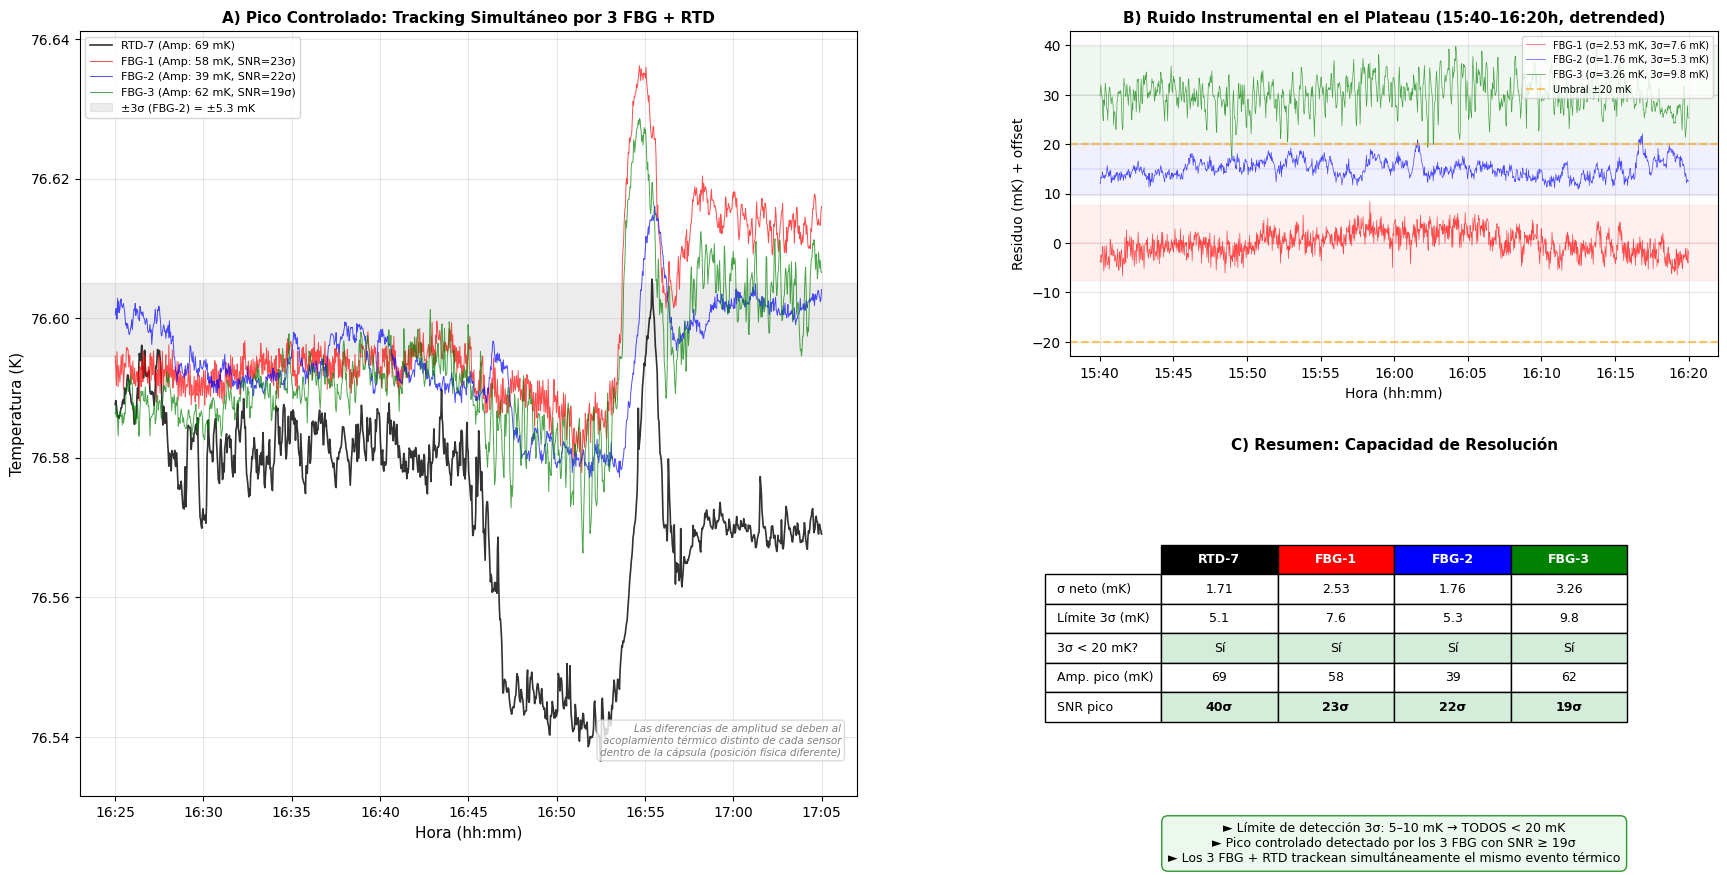

RESUMEN: DEMOSTRACIÓN DE RESOLUCIÓN SUB-20 mK

1. RUIDO INSTRUMENTAL (plateau 15:40–16:20h, detrended):
   RTD-7: σ = 1.71 mK → 3σ = 5.1 mK
   FBG-1: σ = 2.53 mK → 3σ = 7.6 mK
   FBG-2: σ = 1.76 mK → 3σ = 5.3 mK
   FBG-3: σ = 3.26 mK → 3σ = 9.8 mK

2. DETECCIÓN DEL PICO CONTROLADO (16:25–17:05h):
   RTD-7: Amplitud = 69 mK, SNR = 40σ
   FBG-1: Amplitud = 58 mK, SNR = 23σ
   FBG-2: Amplitud = 39 mK, SNR = 22σ
   FBG-3: Amplitud = 62 mK, SNR = 19σ

✅ CONCLUSIÓN: Las 3 FBGs resuelven gradientes ≥ 10 mK (3σ del peor sensor)
   y detectan el pico controlado con SNR ≥ 19σ.
   Todos los sensores tienen 3σ < 20 mK → resolución sub-20 mK confirmada.


In [17]:
import matplotlib
import matplotlib.gridspec as gridspec
# ==============================================================================
# 8.5 DEMOSTRACIÓN DIRECTA DE RESOLUCIÓN SUB-20 mK
# ==============================================================================

DOWNSAMPLE_SEC = 2.0
t_comp_inicio = datetime.datetime.combine(fecha, datetime.time(14, 25))
t_comp_fin_85 = datetime.datetime.combine(fecha, datetime.time(20, 0))
t_baseline_inicio = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_baseline_fin = datetime.datetime.combine(fecha, datetime.time(16, 0))
rtd_ref_idx_85 = 6

# --- Construir datos FBG calibrados ---
mask_temp_85 = (times_temp >= t_comp_inicio) & (times_temp <= t_comp_fin_85) & (temp_raw[:, rtd_ref_idx_85] > 0)
times_temp_85 = times_temp[mask_temp_85]
temp_ref_85 = temp_raw[mask_temp_85, rtd_ref_idx_85]
T0_85 = np.mean(temp_ref_85[(times_temp_85 >= t_baseline_inicio) & (times_temp_85 <= t_baseline_fin)])

sensitivities_85 = {1: 18.863, 2: 19.338, 3: 19.497}
sens_nm_85 = {k: v * 1e-3 for k, v in sensitivities_85.items()}

fbg_85 = {}
for sn in [1, 2, 3]:
    si = sn - 1
    wp = wav_raw[:, 0, si]; ws = wav_raw[:, 1, si]
    mp = (wp > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin_85)
    ms = (ws > 0) & (times_peak >= t_comp_inicio) & (times_peak <= t_comp_fin_85)
    tp_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_peak[mp]])
    ts_sec = np.array([(t - t_comp_inicio).total_seconds() for t in times_peak[ms]])
    wm = (wp[mp] + np.interp(tp_sec, ts_sec, ws[ms])) / 2.0
    dur = (t_comp_fin_85 - t_comp_inicio).total_seconds()
    be = np.arange(0, dur + DOWNSAMPLE_SEC, DOWNSAMPLE_SEC)
    bc = be[:-1] + DOWNSAMPLE_SEC / 2.0
    from scipy import stats as st85
    bm, _, _ = st85.binned_statistic(tp_sec, wm, statistic='mean', bins=be)
    vb = ~np.isnan(bm)
    tds = np.array([t_comp_inicio + datetime.timedelta(seconds=float(s)) for s in bc[vb]])
    wds = bm[vb]
    mr = (tds >= t_baseline_inicio) & (tds <= t_baseline_fin)
    fbg_85[sn] = {'times': tds, 'temp': T0_85 + (wds - np.mean(wds[mr])) / sens_nm_85[sn]}

# RTD-7 downsampled
trs = np.array([(t - t_comp_inicio).total_seconds() for t in times_temp_85])
ber = np.arange(0, (t_comp_fin_85 - t_comp_inicio).total_seconds() + DOWNSAMPLE_SEC, DOWNSAMPLE_SEC)
bcr = ber[:-1] + DOWNSAMPLE_SEC / 2.0
bmr, _, _ = st85.binned_statistic(trs, temp_ref_85, statistic='mean', bins=ber)
vr = ~np.isnan(bmr)
t_rtd = np.array([t_comp_inicio + datetime.timedelta(seconds=float(s)) for s in bcr[vr]])
T_rtd = bmr[vr]

# ==============================================================================
# CÁLCULOS
# ==============================================================================
# --- Ruido neto en plateau (15:40 - 16:20h) ---
t_p_i = datetime.datetime.combine(fecha, datetime.time(15, 40))
t_p_f = datetime.datetime.combine(fecha, datetime.time(16, 20))

sigma_net = {}; sigma_raw = {}
residuals_plateau = {}  # Para Panel B
for sn in [1, 2, 3]:
    mp = (fbg_85[sn]['times'] >= t_p_i) & (fbg_85[sn]['times'] <= t_p_f)
    Tp = fbg_85[sn]['temp'][mp]
    tp_fbg = fbg_85[sn]['times'][mp]
    xp = np.array([(t - t_p_i).total_seconds() for t in tp_fbg])
    sl, ic, _, _, _ = st85.linregress(xp, Tp)
    res = (Tp - (sl * xp + ic)) * 1000.0  # mK
    sigma_net[sn] = np.std(res)
    sigma_raw[sn] = np.std(Tp) * 1000.0
    residuals_plateau[sn] = {'times': tp_fbg, 'res': res}

# RTD noise in plateau
mpr = (t_rtd >= t_p_i) & (t_rtd <= t_p_f)
Tpr = T_rtd[mpr]
xpr = np.array([(t - t_p_i).total_seconds() for t in t_rtd[mpr]])
slr, icr, _, _, _ = st85.linregress(xpr, Tpr)
sigma_rtd = np.std(Tpr - (slr * xpr + icr)) * 1000.0

# --- Amplitud del pico por sensor (16:25 - 17:05h) ---
t_pk_i = datetime.datetime.combine(fecha, datetime.time(16, 25))
t_pk_f = datetime.datetime.combine(fecha, datetime.time(17, 5))

peak_amp = {}
for sn in [1, 2, 3]:
    mask = (fbg_85[sn]['times'] >= t_pk_i) & (fbg_85[sn]['times'] <= t_pk_f)
    peak_amp[sn] = (np.max(fbg_85[sn]['temp'][mask]) - np.min(fbg_85[sn]['temp'][mask])) * 1000.0

mask_rtd_pk = (t_rtd >= t_pk_i) & (t_rtd <= t_pk_f)
peak_amp_rtd = (np.max(T_rtd[mask_rtd_pk]) - np.min(T_rtd[mask_rtd_pk])) * 1000.0

# SNR = amplitud / sigma_net
snr = {sn: peak_amp[sn] / sigma_net[sn] for sn in [1, 2, 3]}

# ==============================================================================
# FIGURE: 3 PANELES
# ==============================================================================
fig = plt.figure(figsize=(18, 9))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1],
                       hspace=0.35, wspace=0.30)
ax_peak = fig.add_subplot(gs[:, 0])   # Panel A: tracking del pico
ax_noise = fig.add_subplot(gs[0, 1])  # Panel B: ruido en plateau
ax_tab = fig.add_subplot(gs[1, 1])    # Panel C: tabla resumen

colors_85 = {1: 'red', 2: 'blue', 3: 'green'}

# === PANEL A: Tracking del pico controlado ===
mask_rtd_z = (t_rtd >= t_pk_i) & (t_rtd <= t_pk_f)
ax_peak.plot(t_rtd[mask_rtd_z], T_rtd[mask_rtd_z], 'k-', linewidth=1.2, alpha=0.8,
             label=f'RTD-7 (Amp: {peak_amp_rtd:.0f} mK)')

for sn in [1, 2, 3]:
    mask = (fbg_85[sn]['times'] >= t_pk_i) & (fbg_85[sn]['times'] <= t_pk_f)
    ax_peak.plot(fbg_85[sn]['times'][mask], fbg_85[sn]['temp'][mask],
                color=colors_85[sn], linewidth=0.7, alpha=0.7,
                label=f'FBG-{sn} (Amp: {peak_amp[sn]:.0f} mK, SNR={snr[sn]:.0f}σ)')

# Banda 3σ del mejor sensor
sigma_best = min(sigma_net.values())
t_pre = datetime.datetime.combine(fecha, datetime.time(16, 28))
mask_pre = (fbg_85[2]['times'] >= t_pk_i) & (fbg_85[2]['times'] <= t_pre)
y_base = np.mean(fbg_85[2]['temp'][mask_pre]) if np.sum(mask_pre) > 0 else T0_85
ax_peak.axhspan(y_base - 3*sigma_best/1000, y_base + 3*sigma_best/1000,
                color='gray', alpha=0.15, label=f'±3σ (FBG-2) = ±{3*sigma_best:.1f} mK')

ax_peak.set_title('A) Pico Controlado: Tracking Simultáneo por 3 FBG + RTD',
                   fontsize=11, fontweight='bold')
ax_peak.set_ylabel('Temperatura (K)', fontsize=11)
ax_peak.set_xlabel('Hora (hh:mm)', fontsize=11)
ax_peak.grid(True, alpha=0.3)
ax_peak.legend(loc='upper left', fontsize=8)
ax_peak.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))

# Anotar texto explicativo
ax_peak.text(0.98, 0.05,
             'Las diferencias de amplitud se deben al\nacoplamiento térmico distinto de cada sensor\ndentro de la cápsula (posición física diferente)',
             transform=ax_peak.transAxes, fontsize=7.5, ha='right', va='bottom',
             style='italic', color='gray',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=0.8))

# === PANEL B: Ruido detrended en el plateau ===
for sn in [1, 2, 3]:
    offset = (sn - 1) * 15  # Offset vertical para claridad
    ax_noise.plot(residuals_plateau[sn]['times'], residuals_plateau[sn]['res'] + offset,
                 color=colors_85[sn], linewidth=0.5, alpha=0.7,
                 label=f'FBG-{sn} (σ={sigma_net[sn]:.2f} mK, 3σ={3*sigma_net[sn]:.1f} mK)')
    # Linea de referencia y bandas ±3σ
    ax_noise.axhline(offset, color=colors_85[sn], linewidth=0.3, alpha=0.3)
    ax_noise.axhspan(offset - 3*sigma_net[sn], offset + 3*sigma_net[sn],
                     color=colors_85[sn], alpha=0.06)

# Marcar umbral 20 mK como referencia
ax_noise.axhline(20, color='orange', linewidth=1.5, linestyle='--', alpha=0.6)
ax_noise.axhline(-20, color='orange', linewidth=1.5, linestyle='--', alpha=0.6,
                 label='Umbral ±20 mK')

ax_noise.set_title('B) Ruido Instrumental en el Plateau (15:40–16:20h, detrended)',
                    fontsize=11, fontweight='bold')
ax_noise.set_ylabel('Residuo (mK) + offset', fontsize=10)
ax_noise.set_xlabel('Hora (hh:mm)', fontsize=10)
ax_noise.legend(loc='upper right', fontsize=7)
ax_noise.grid(True, alpha=0.3)
ax_noise.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))

# === PANEL C: Tabla resumen ===
ax_tab.axis('off')
col_labels = ['RTD-7', 'FBG-1', 'FBG-2', 'FBG-3']
row_labels = ['σ neto (mK)', 'Límite 3σ (mK)', '3σ < 20 mK?',
              'Amp. pico (mK)', 'SNR pico']

table_data = [
    [f'{sigma_rtd:.2f}', f'{sigma_net[1]:.2f}', f'{sigma_net[2]:.2f}', f'{sigma_net[3]:.2f}'],
    [f'{3*sigma_rtd:.1f}', f'{3*sigma_net[1]:.1f}', f'{3*sigma_net[2]:.1f}', f'{3*sigma_net[3]:.1f}'],
    ['Sí' if 3*sigma_rtd < 20 else 'No',
     'Sí' if 3*sigma_net[1] < 20 else 'No',
     'Sí' if 3*sigma_net[2] < 20 else 'No',
     'Sí' if 3*sigma_net[3] < 20 else 'No'],
    [f'{peak_amp_rtd:.0f}', f'{peak_amp[1]:.0f}', f'{peak_amp[2]:.0f}', f'{peak_amp[3]:.0f}'],
    [f'{peak_amp_rtd/sigma_rtd:.0f}σ', f'{snr[1]:.0f}σ', f'{snr[2]:.0f}σ', f'{snr[3]:.0f}σ'],
]

table = ax_tab.table(cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
                     cellLoc='center', loc='center', colWidths=[0.18, 0.18, 0.18, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.6)

# Header colors
header_colors = ['black', 'red', 'blue', 'green']
for j in range(len(col_labels)):
    table[0, j].set_facecolor(header_colors[j])
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color 3σ < 20 mK row
for j in range(len(col_labels)):
    table[3, j].set_facecolor('#d4edda')  # All pass

# Color SNR row
for j in range(len(col_labels)):
    table[5, j].set_facecolor('#d4edda')
    table[5, j].set_text_props(fontweight='bold')

ax_tab.set_title('C) Resumen: Capacidad de Resolución', fontsize=11, fontweight='bold', pad=15)

# Conclusión
max_3sigma = max(3*sigma_net[sn] for sn in [1, 2, 3])
min_snr = min(snr.values())
conclusion = (f'► Límite de detección 3σ: {3*min(sigma_net.values()):.0f}–{max_3sigma:.0f} mK → TODOS < 20 mK' + '\n' +
              f'► Pico controlado detectado por los 3 FBG con SNR ≥ {min_snr:.0f}σ' + '\n' +
              f'► Los 3 FBG + RTD trackean simultáneamente el mismo evento térmico')
ax_tab.text(0.5, -0.08, conclusion, transform=ax_tab.transAxes,
            fontsize=9, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f5e9', edgecolor='green', alpha=0.8))

fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.08)
plt.show()

# --- Resumen impreso ---
print('=' * 80)
print('RESUMEN: DEMOSTRACIÓN DE RESOLUCIÓN SUB-20 mK')
print('=' * 80)
print(f'\n1. RUIDO INSTRUMENTAL (plateau 15:40–16:20h, detrended):')
print(f'   RTD-7: σ = {sigma_rtd:.2f} mK → 3σ = {3*sigma_rtd:.1f} mK')
for sn in [1, 2, 3]:
    print(f'   FBG-{sn}: σ = {sigma_net[sn]:.2f} mK → 3σ = {3*sigma_net[sn]:.1f} mK')
print(f'\n2. DETECCIÓN DEL PICO CONTROLADO (16:25–17:05h):')
print(f'   RTD-7: Amplitud = {peak_amp_rtd:.0f} mK, SNR = {peak_amp_rtd/sigma_rtd:.0f}σ')
for sn in [1, 2, 3]:
    print(f'   FBG-{sn}: Amplitud = {peak_amp[sn]:.0f} mK, SNR = {snr[sn]:.0f}σ')
print(f'\n✅ CONCLUSIÓN: Las 3 FBGs resuelven gradientes ≥ {max_3sigma:.0f} mK (3σ del peor sensor)')
print(f'   y detectan el pico controlado con SNR ≥ {min_snr:.0f}σ.')
print(f'   Todos los sensores tienen 3σ < 20 mK → resolución sub-20 mK confirmada.')


## 📊 **Plot: Espectro Individual en Tiempo Específico**

Visualiza el espectro completo de un sensor FBG en un instante temporal determinado. Útil para analizar la forma del pico, FWHM, y calidad de la medición.

📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-6, 17/07/2026)

✅ Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

📊 Estructura de datos:
   't': shape=(1, 2), dtype=float64
   'wav': shape=(1, 2, 1, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (1, 2, 1, 39200)
      → Dimensiones: (n_entries=1, dim1=2, dim2=1, n_points=39200)

   ⏰ Timestamps ('t'):
      Shape: (1, 2)
      Primeros valores: [1.78464085e+09 1.78464086e+09]

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   ✅ Usando timestamps de 'spectrum.t'
   Timestamps shape: (515, 2) → usando columna 0
   Tiempo objetivo:     2026-07-21 15:15:00
   Tiempo más cercano:  2026-07-21 15:34:14
   Diferencia:          1154.3 segundos
   Índice del evento:   0

📊 Datos cargados del tree 'spectrum':
   Shape raw: (1, 2, 1, 39200)
   → Estructura 4D detectada, extrayendo primera entrada: (2, 1, 39200)

📊 Datos del evento listo para procesar:
   Shape final: (2, 1, 39200)
   Tamaño tot

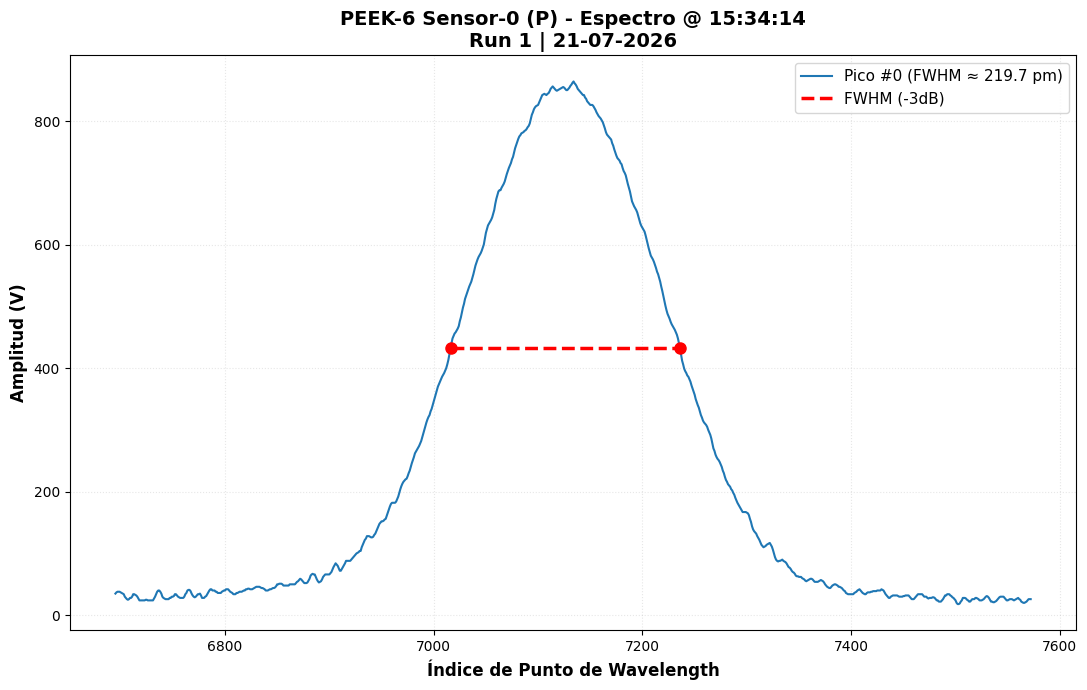


✅ Plot generado exitosamente


In [18]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 7, 21, 15, 15, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (PEEK-6, 17/07/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"PEEK-6 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        # Extraer valores escalares (results_half retorna arrays, tomamos primer elemento)
        fwhm_height = results_half[1][0] if hasattr(results_half[1], '__len__') else results_half[1]
        fwhm_left = results_half[2][0] if hasattr(results_half[2], '__len__') else results_half[2]
        fwhm_right = results_half[3][0] if hasattr(results_half[3], '__len__') else results_half[3]
        
        plt.hlines(fwhm_height, fwhm_left, fwhm_right, 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([fwhm_left, fwhm_right], [fwhm_height, fwhm_height], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\nRun 1 | 21-07-2026", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\nRun 1 | 21-07-2026", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")